In [2]:
from first_part import *
import anndata as ad
from statsmodels.stats.multitest import multipletests 
import matplotlib
import scanpy as sc
from utils import *
atac_input_file_name = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Nov24.h5ad"
outdir = "./outdir/"

In [3]:
##Load data
adata = sc.read_h5ad(atac_input_file_name)
adata = prepareData(adata)
adata

/Users/eloiseberson/code/PD-epigenomic-analysis/src/utils.py:104: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["condition2"] = adata.obs["condition"].replace({"LRRK2-PD-":"LRRK2", "LRRK2-PD+":"LRRK2"}).values


AnnData object with n_obs × n_vars = 2358 × 42352
    obs: 'celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch', 'PatientID', 'Unnamed: 0', 'Sample_id', 'Name', 'OldName', 'NewName', 'HarmonizedName', 'Bam', 'Contrast', 'Type', 'Group', 'Region', 'RegionMod', 'PatientIDMod', 'TypeMod', 'Cohort', 'TissueCenter', 'TypeGroup', 'xxx.TechRep', 'Batch', 'xxx.Sample', 'xxx.Library', 'xxx.BioRep', 'xxx.TechRep.1', 'Pool', 'xxx.race', 'Gender', 'age at death', 'PMI', 'Mutation', 'MutationType', 'xxx.last_mmse_test_score', 'ApoE', 'xxx.last_mmse_test_date', 'xxx.motor_updrs_score_on', 'xxx.motor_updrs_score_off', 'xxx.motor_updrs_score_months_prior_to_death', 'xxx.Control', 'xxx.AD', 'xxx.PD', 'xxx.DLB', 'xxx.VAD', 'xxx.PSP', 'xxx.HS', 'xxx.DLDH', 'xxx.MND', 'xxx.CBD', 'xxx.PICKS', 'xxx.HD', 'xxx.MSA', 'xxx.ARG', 'xxx.CWMR', 'xxx.dementia_nos', 'xxx.MS', 'xxx.CAA', 'xxx.MCI', 'xxx.LBS', 'xxx.BRAIN_ABNORMAL', 'xxx.ACUTE_INFARCTS', 'xxx.PlaqueF', 'xxx.PlaqueT', 'xxx.PlaqueP', 'xxx.

In [4]:
adata.obs.groupby(['condition',  'ApoE_4']).PatientID.nunique()

condition  ApoE_4
CTRL       0         12
           1          3
GBA1-PD+   0         10
           1          5
LRRK2-PD+  0          2
           1          1
SPOR       0         11
           1          4
Name: PatientID, dtype: int64

In [5]:
adata.obs["ApoE_4"] = adata.obs["ApoE_4"].map({0:"E4-",1:"E4+"}).values
COLORS_CT["E4-"] = "#F6E8C3"
COLORS_CT["E4+"] = "#003C30"

In [6]:
adata.obs.condition.unique()

array(['CTRL', 'SPOR', 'GBA1-PD+', 'LRRK2-PD+'], dtype=object)

In [7]:
adata.obs.condition = adata.obs.condition.map({"GBA1-PD+":"GBA1",'LRRK2-PD+':"LRRK2", "CTRL":"CTRL","SPOR":"SPOR"})
adata = adata[adata.obs.condition !="CTRL"]

/Users/eloiseberson/code/PD-epigenomic-analysis/src/first_part.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'sex':'Sex','condition':'Condition'},inplace=True)


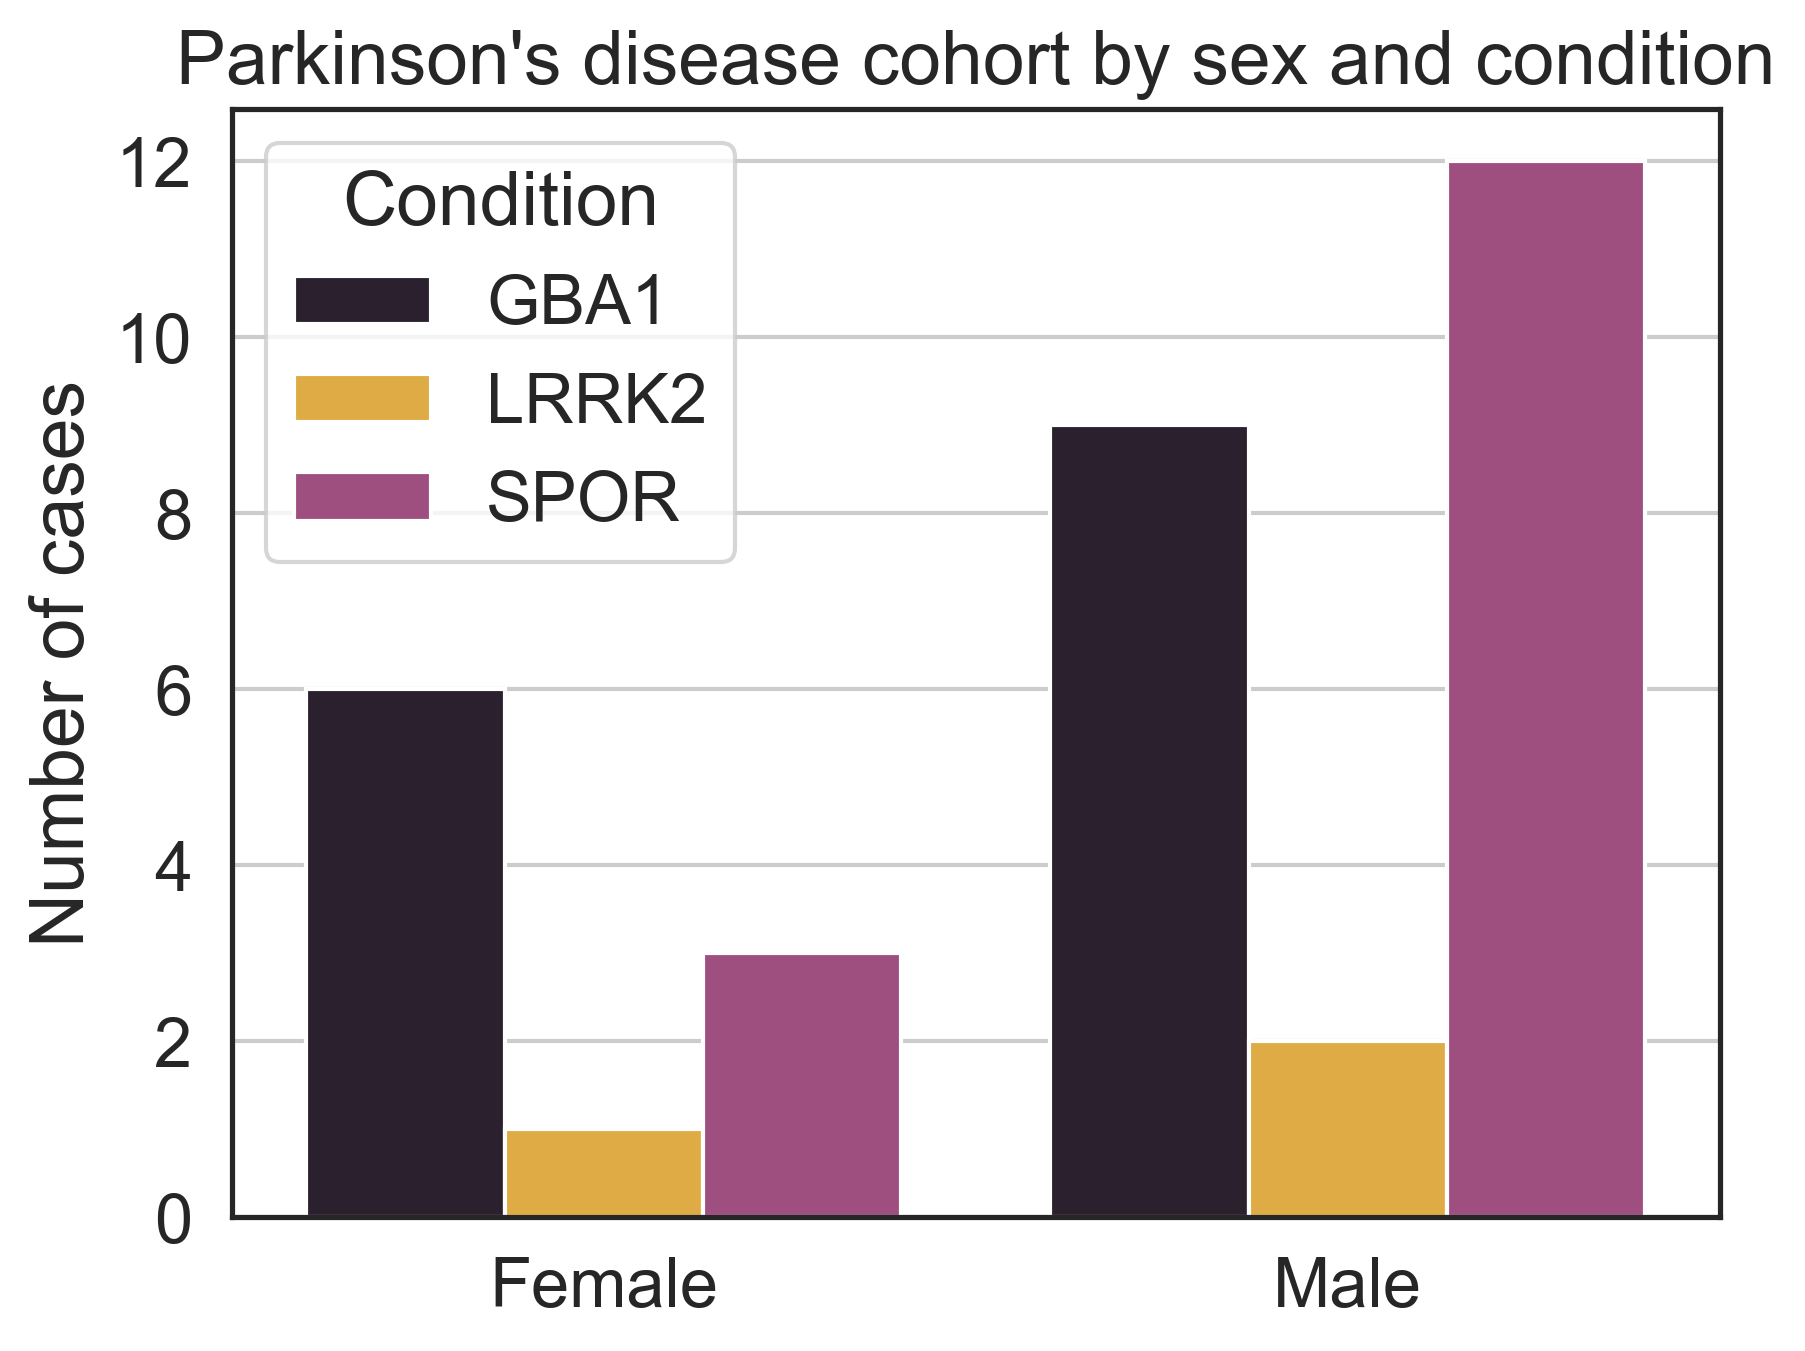

In [8]:
plot_cond_and_sex(adata, outdir)

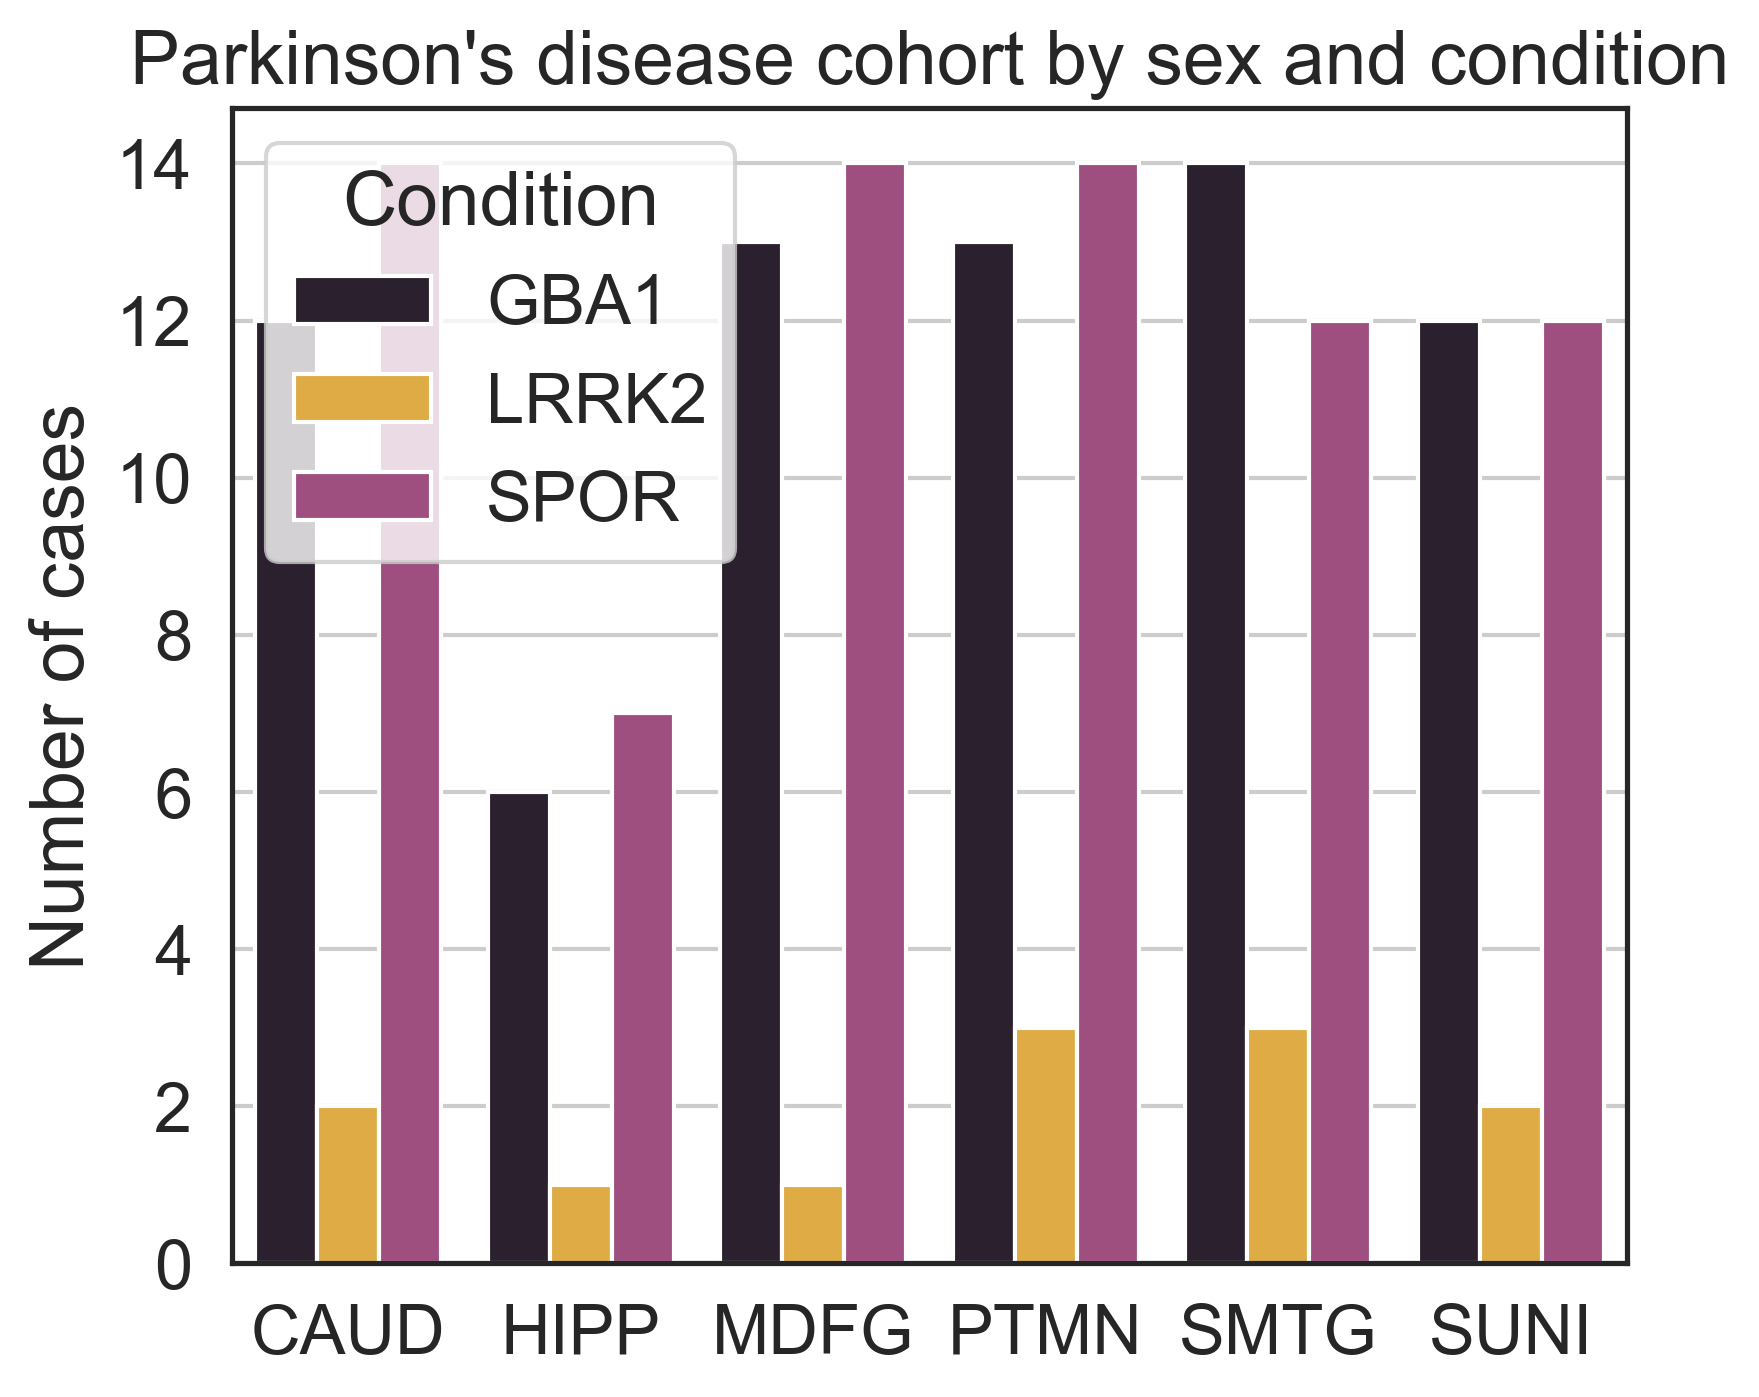

In [9]:
# adata = adata[adata.obs.condition.isin(['CTRL', 'SPOR',  'GBA1_PD+', 'LRRK2_PD+'])]
# adata= ad.read_h5ad(atac_input_file_name)

plot_cond_and_region(adata,outdir)

### Plot description of the cohort with principal putative covariates and cell-type specific UMAP's

In [10]:
print(sns.__version__)

0.13.2


/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_28389/1612572119.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["condition"] = adata.obs["condition"].replace({"GBA1_PD+":"GBA1", "GBA1_PD-":"GBA1", "LRRK2_PD+":"LRRK2", "LRRK2_PD-":"LRRK2"})


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1 vs. LRRK2: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.303e-02 (ns) U_stat=7.500e+00
LRRK2 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.287e-01 U_stat=4.250e+01
GBA1 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.334e-02 (ns) U_stat=6.850e+01


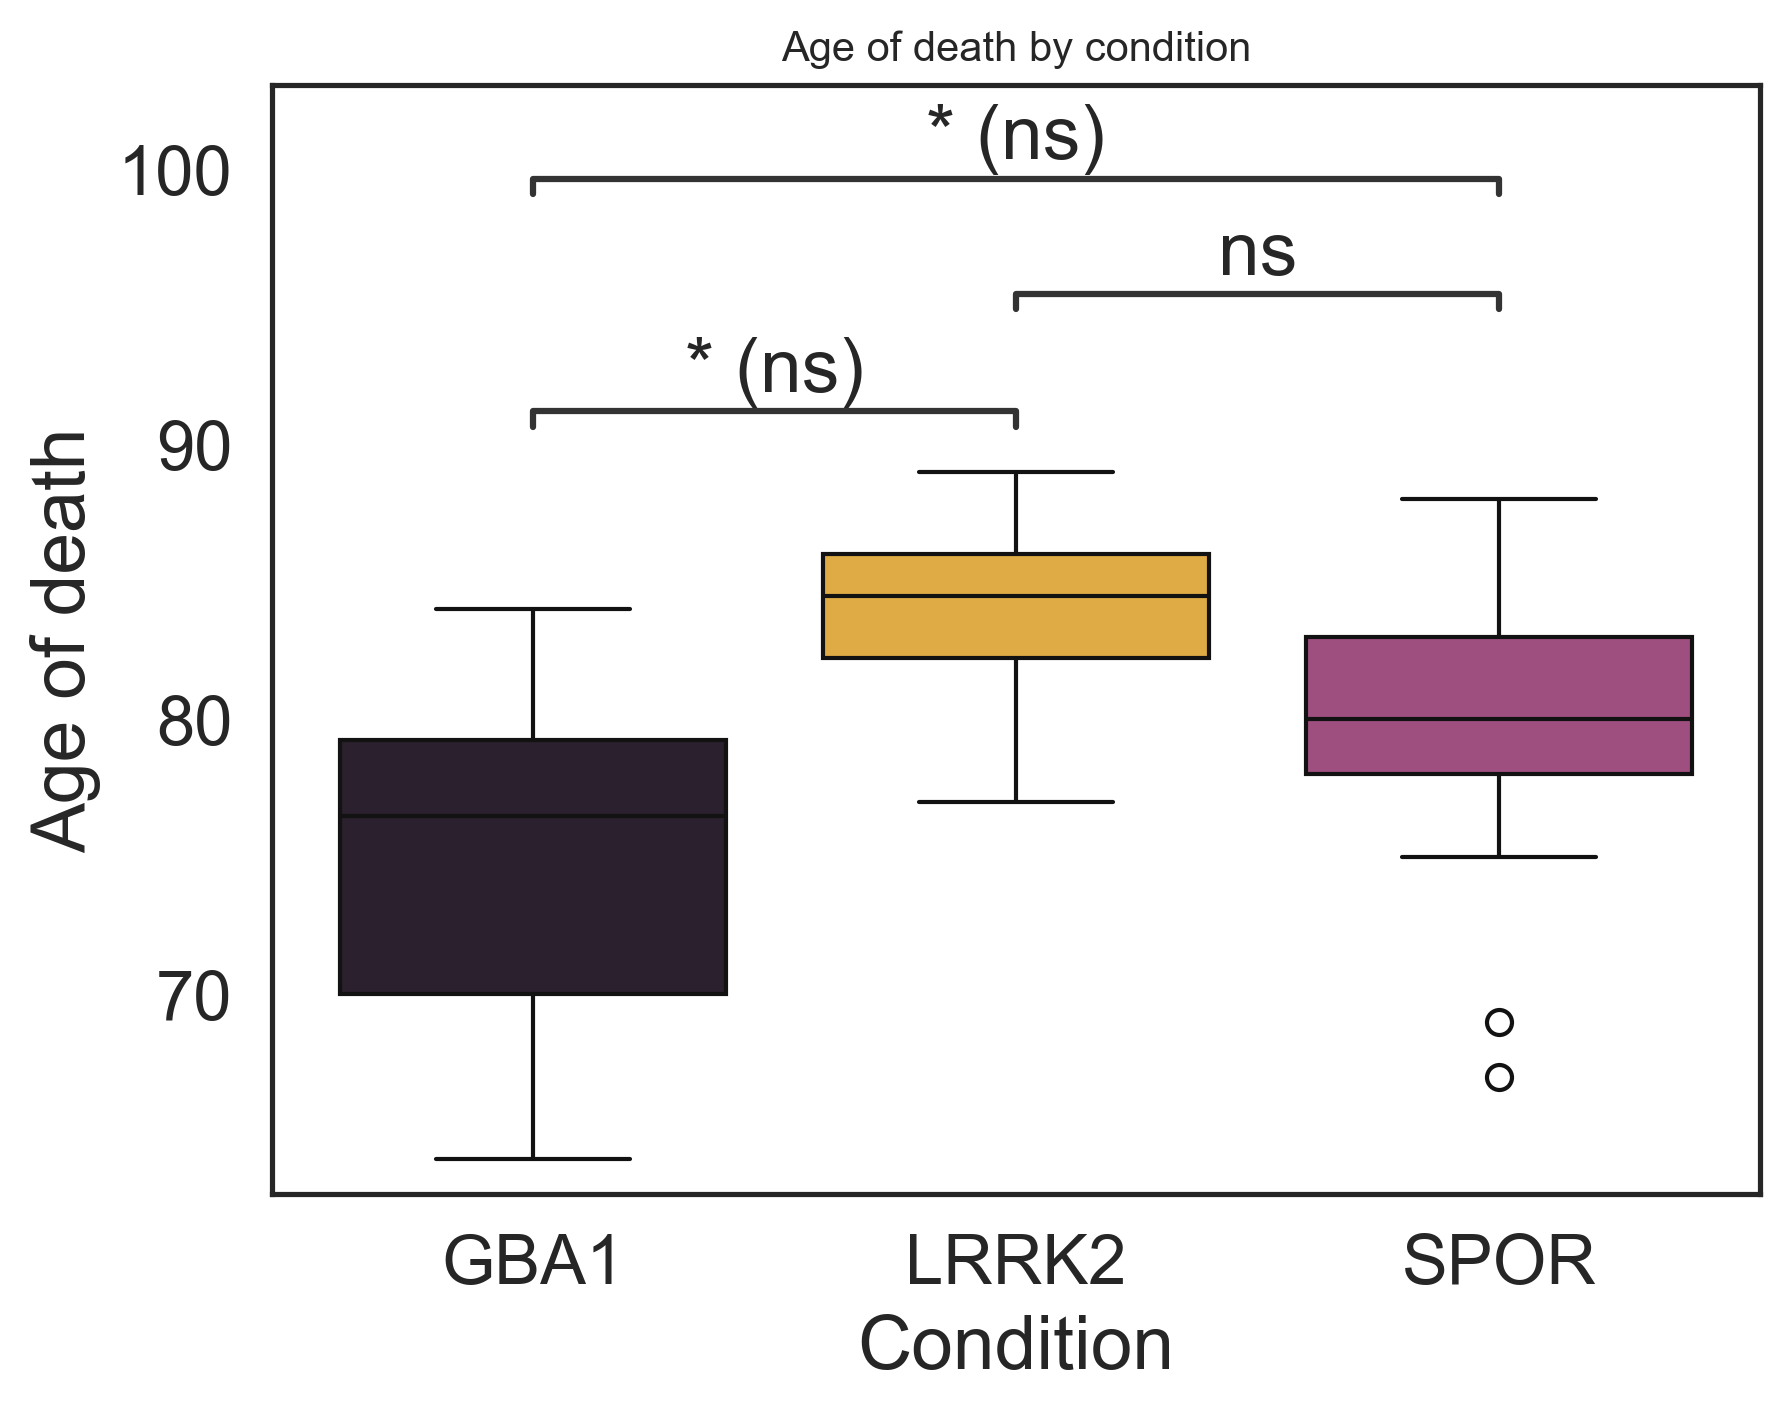

In [11]:
sns.set(style="white", font_scale=1.5)
adata = sc.read_h5ad(atac_input_file_name)
adata = adata[adata.obs.condition !="CTRL"]
adata.obs["condition"] = adata.obs["condition"].replace({"GBA1_PD+":"GBA1", "GBA1_PD-":"GBA1", "LRRK2_PD+":"LRRK2", "LRRK2_PD-":"LRRK2"})
plot_cond_and_age(adata,outdir)

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 42352 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


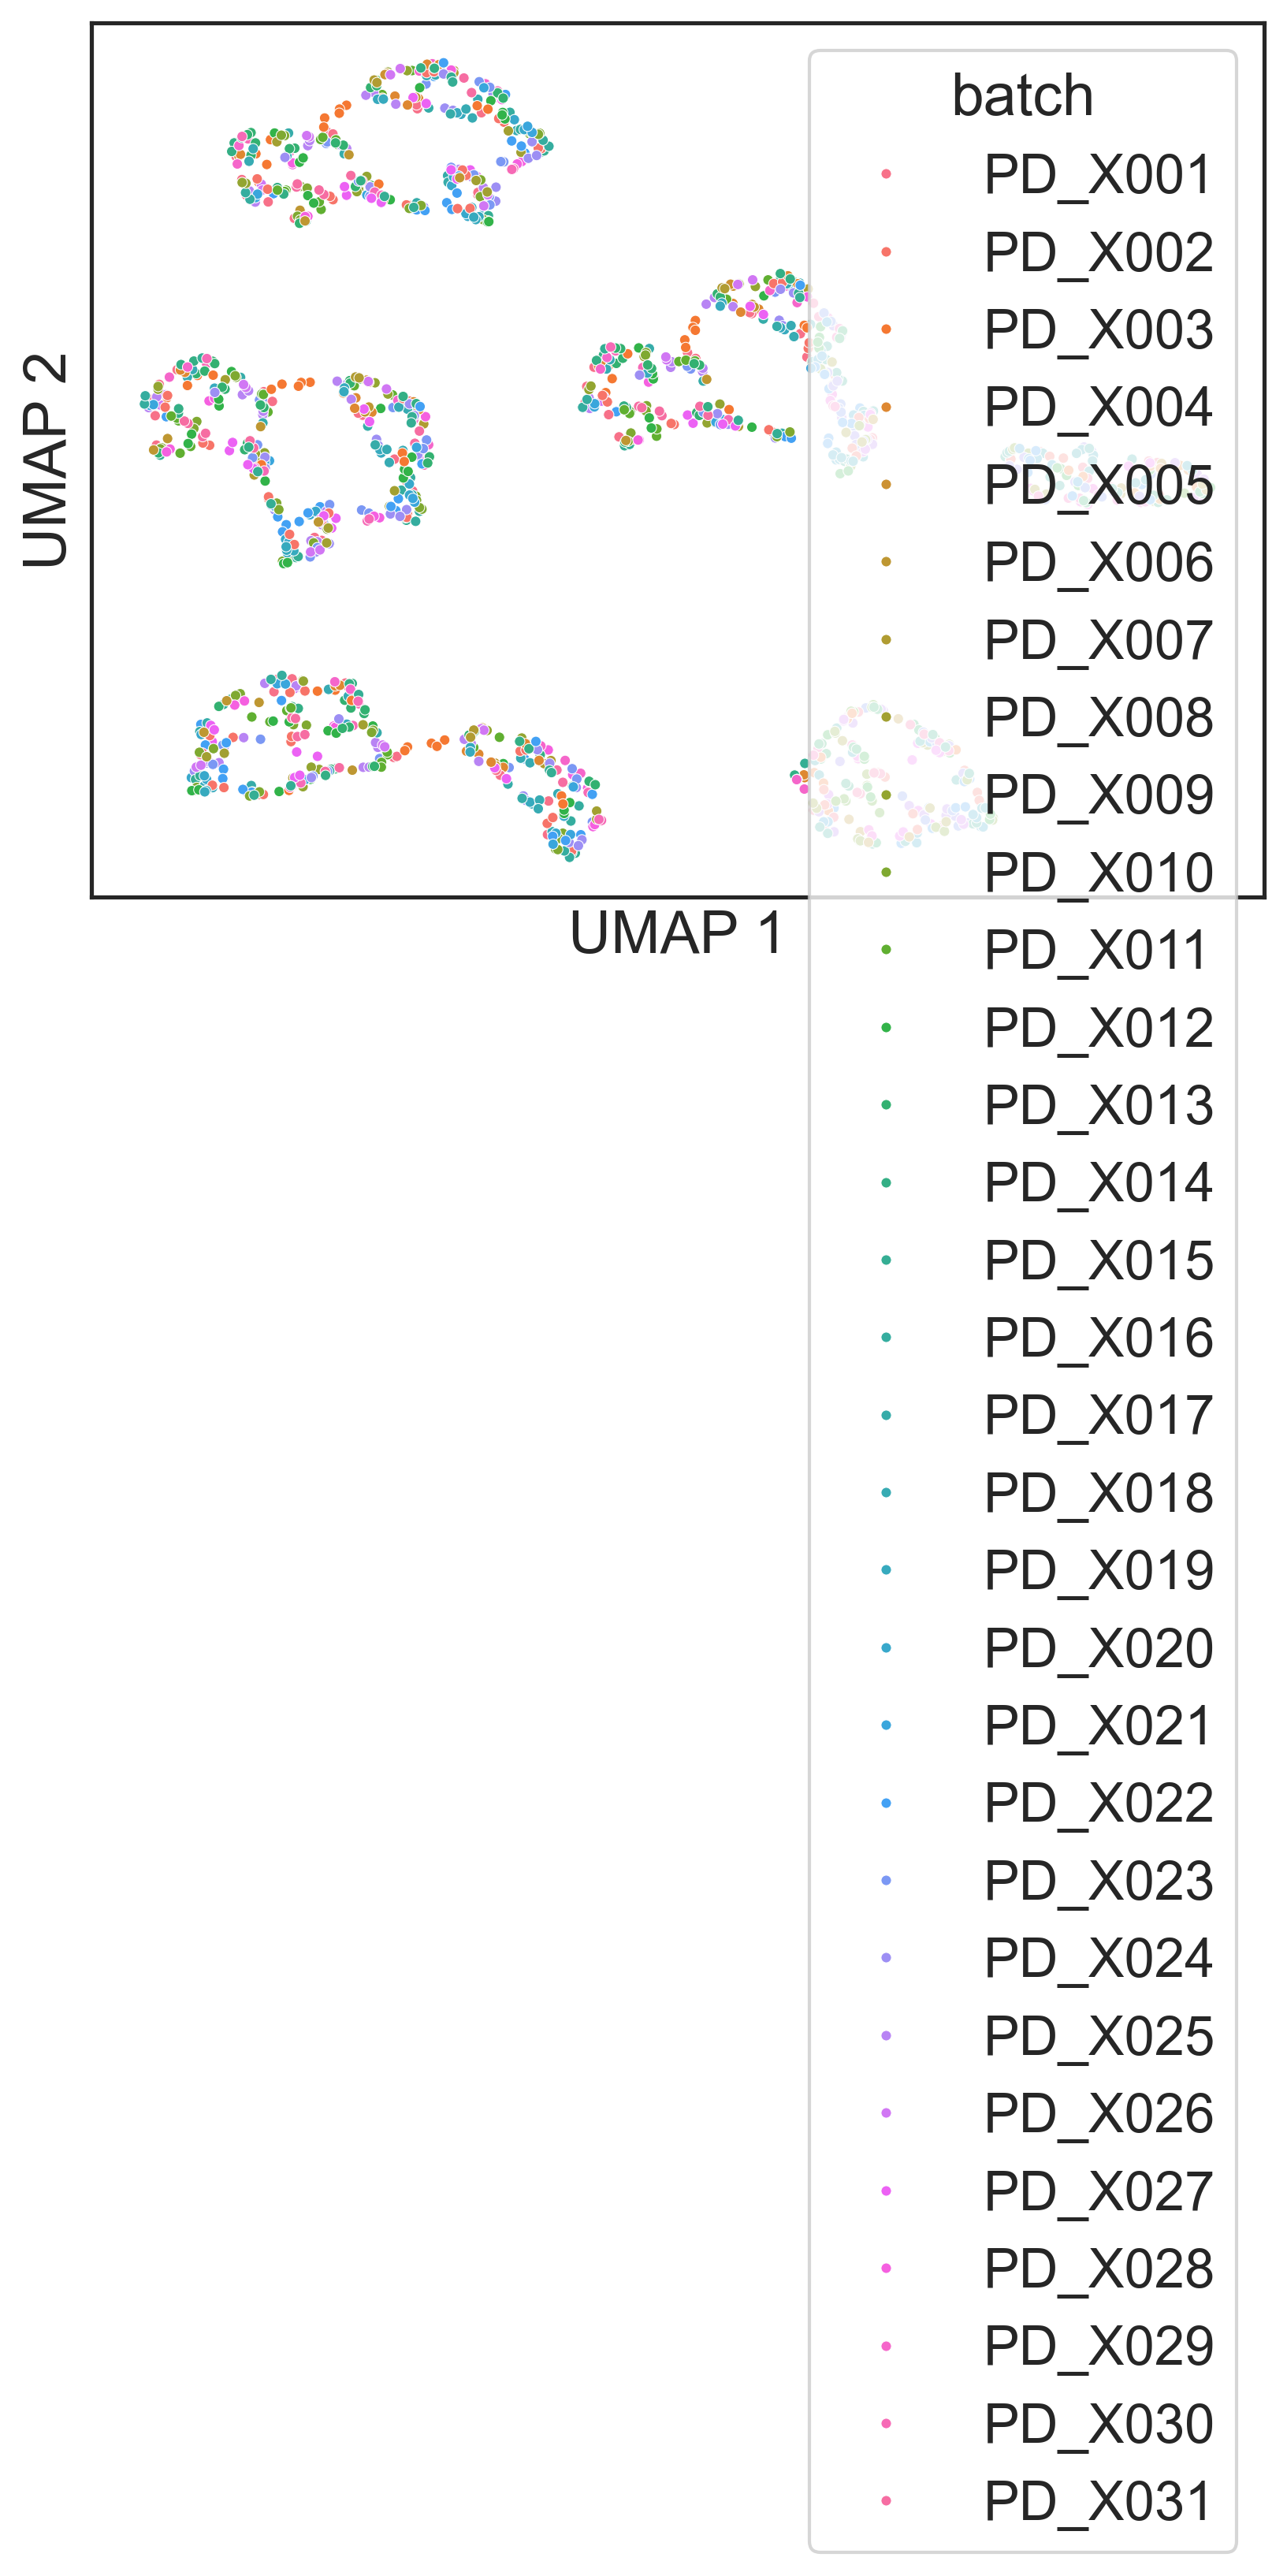

In [12]:
## before removing batch effect
plot_umap_celltype_specific_ct_covariate(adata, "batch", outdir)

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 42352 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


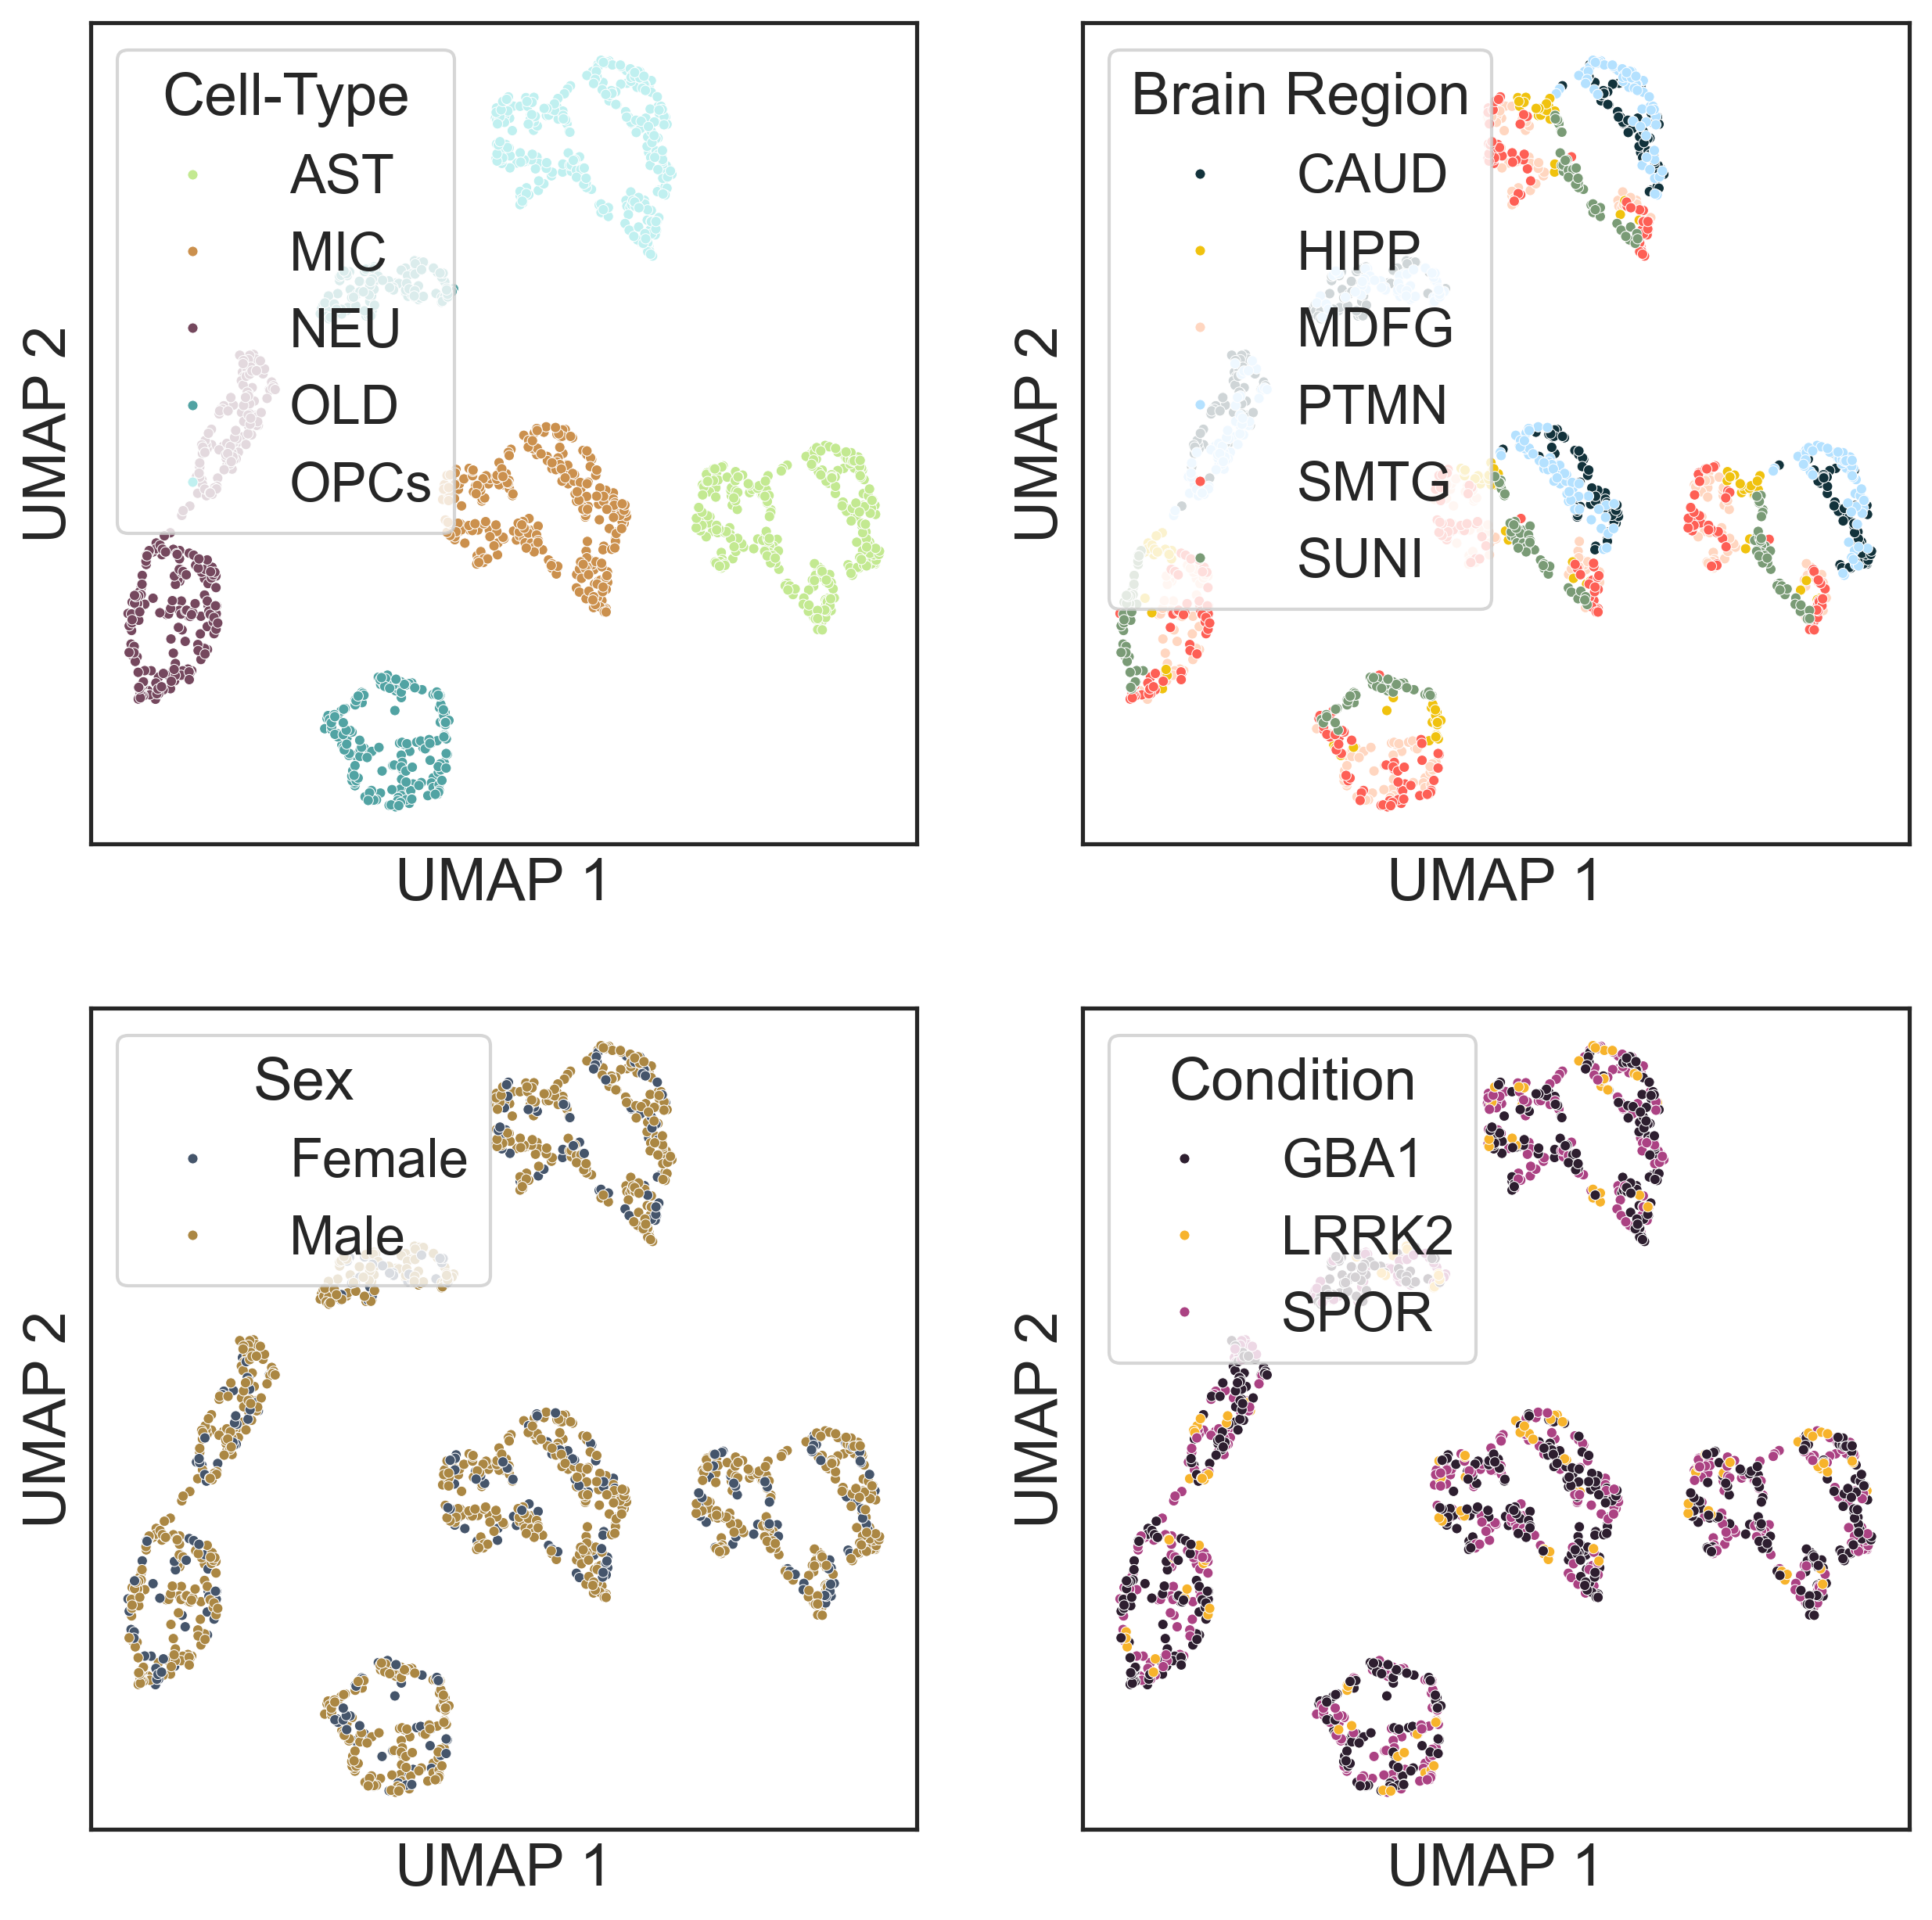

In [13]:
plot_all_umap(adata,outdir,nn=10)

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


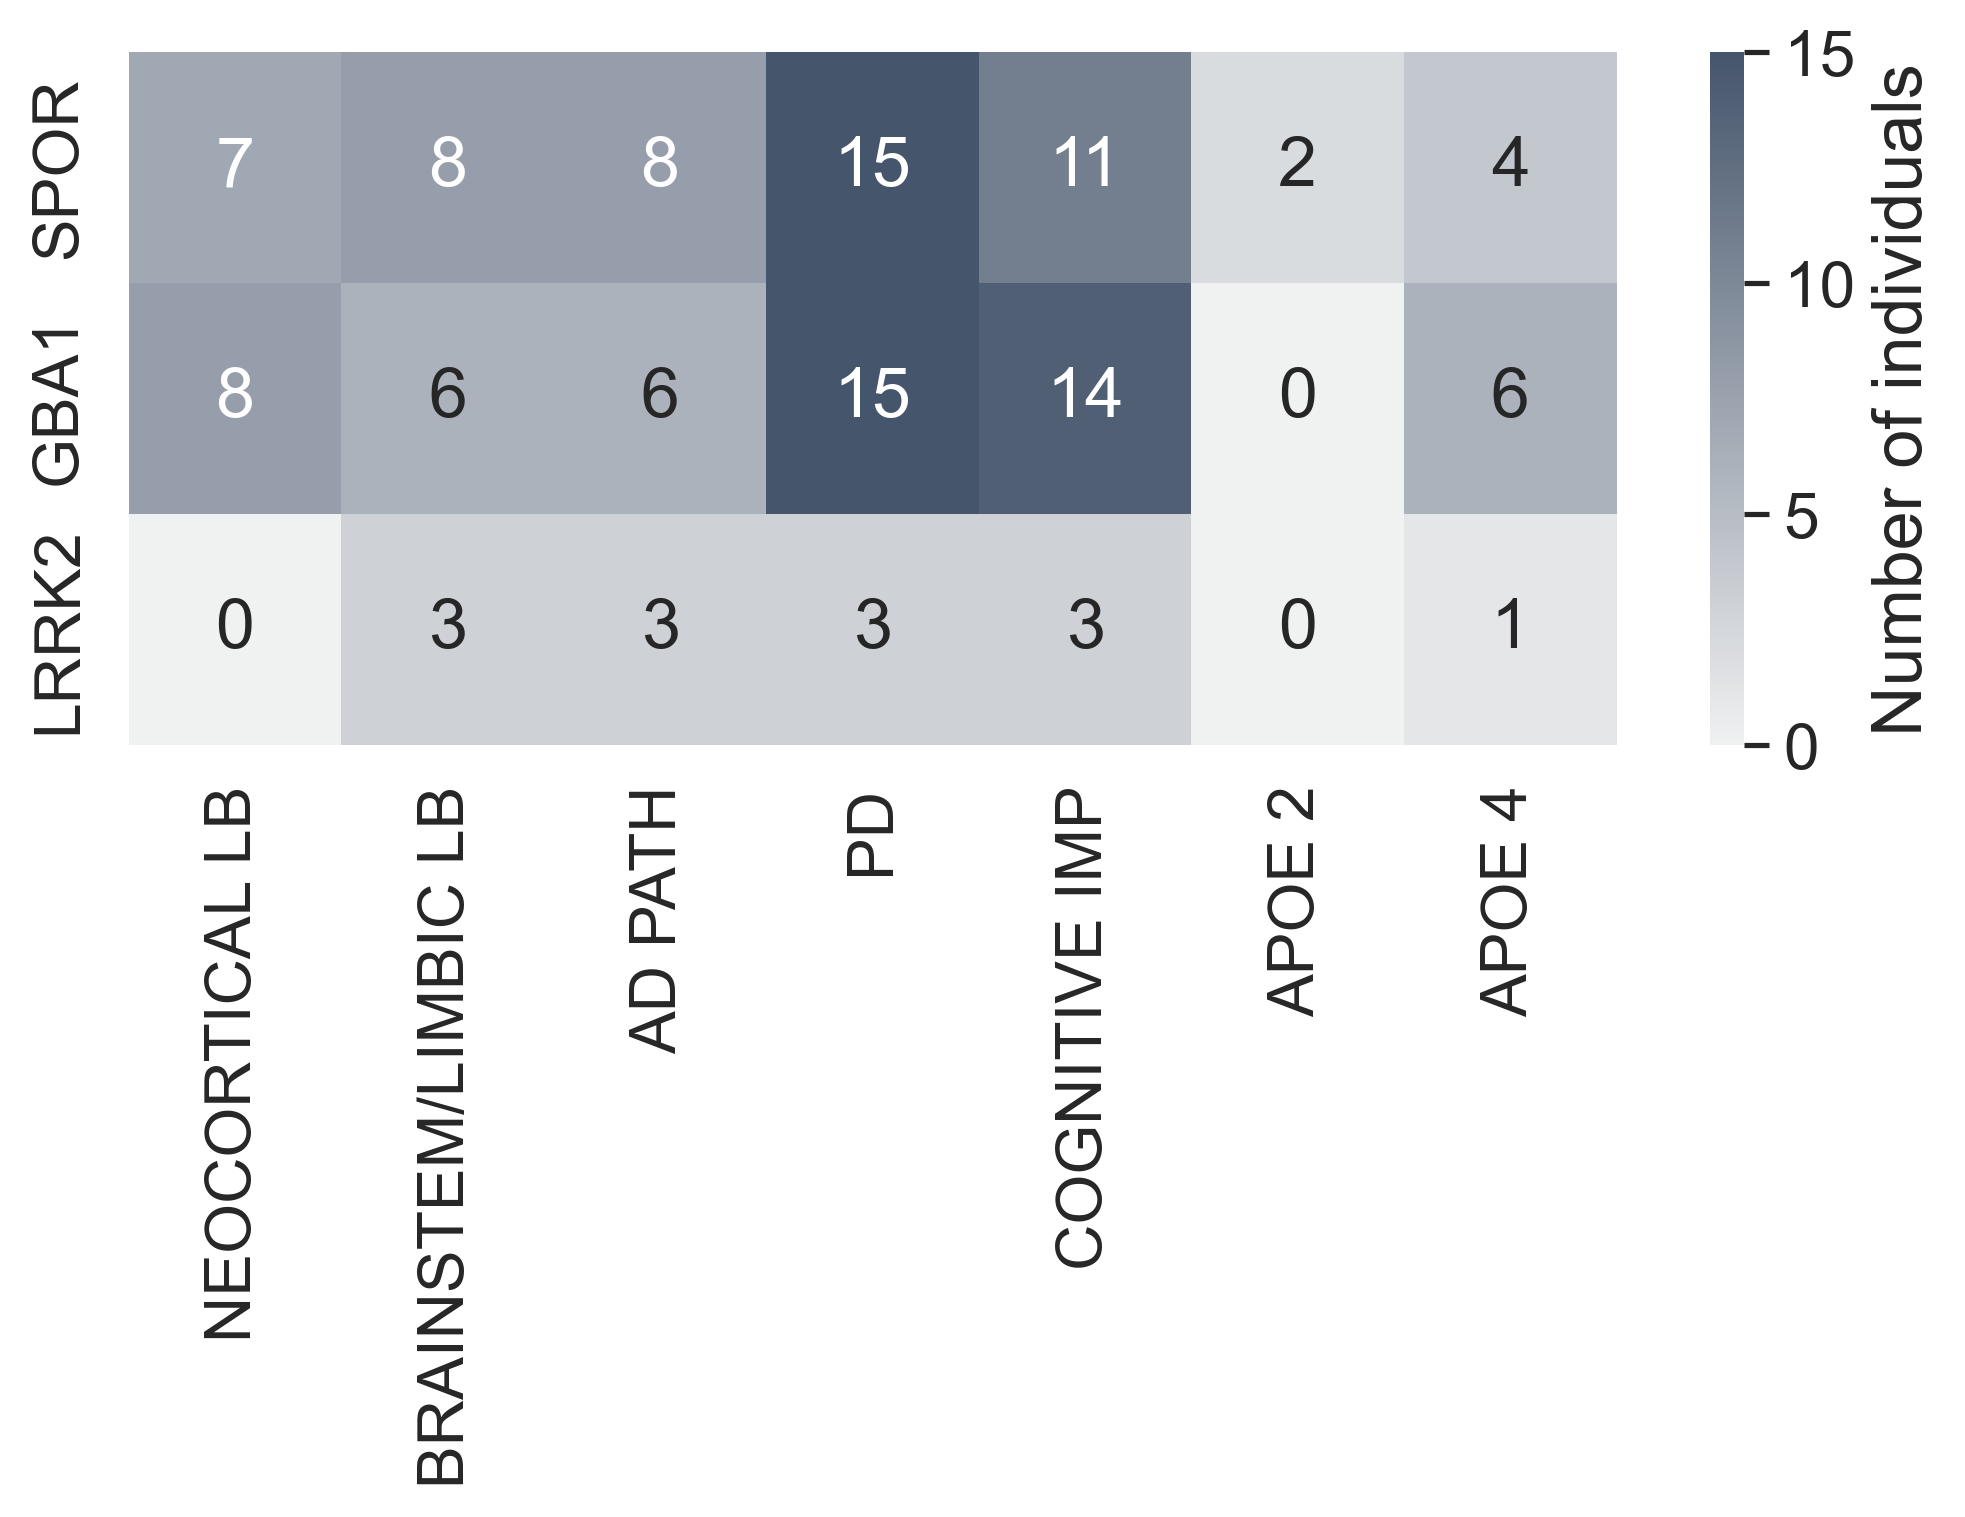

In [14]:
phenotype = ["SPOR", "GBA1",  "LRRK2"]
# pathology = ["Neocortical LB", "Brainstem/Limbic LB","Neuritic plaque density binary", "Braak score NFT binary"]#, "xxx.obt",'xxx.brain_stem_ix_x', 'xxx.brain_stem_lc', 'xxx.bf_amygdala', 'xxx.brain_stem_sn',
           # 'xxx.bf_trans', 'xxx.bf_cing', 'xxx.nctx_temporal', 'xxx.nctx_frontal','xxx.nctx_parietal']
functional = [ "Neocortical LB", "Brainstem/Limbic LB", "AD path", 'xxx.PD', "Cognitive Imp"]
genotype= ["ApoE_2", "ApoE_4"]

tmp = adata.obs[["PatientID"] + phenotype +  functional + genotype].replace({"no":0, "yes":1, "low/no":0,"moderate/high":1}).astype(float)
tmp

def getpvalue(x, y):
    val_ind = np.where((x!=np.nan)&(y!=np.nan))
    x = x[val_ind]
    y = y[val_ind]
    _, pval = spearmanr(x,y)
    return pval
def getspearman(x, y):
    val_ind = np.where((x!=np.nan)&(y!=np.nan))
    x = x[val_ind]
    y = y[val_ind]
    sp, _ = spearmanr(x,y)
    return sp

def getnum(x, y):
    val_ind = np.where((x!=np.nan)&(y!=np.nan))[0]
    x = x[val_ind]
    y = y[val_ind]

    num = np.where((y==1) &(x==1) &(x==y))[0]
    # print(num)
    return len(num)



# for nam,it in dico.items():
if True:
    tmp = adata.obs[["PatientID"] + phenotype +  functional + genotype].replace({"no":0, "yes":1, "low/no":0,"moderate/high":1}).astype(float)
    tmp = tmp.drop_duplicates("PatientID").drop("PatientID",axis=1)

    p = tmp.corr(method=getpvalue)
    
    mat = tmp.corr(method=getnum)
    print(adata.obs.columns)
    mat = mat.loc[phenotype,:][ functional + genotype]
    p = p.loc[phenotype,:][ functional + genotype]
    mat.columns = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in mat.columns.tolist()]
    p.columns = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in p.columns.tolist()]
    mat.index = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in mat.index.tolist()]
    p.index = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in p.index.tolist()]
    
    p = p*p.shape[0]*p.shape[1]
    p = p.applymap(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))

    sns.set(font_scale=1.4,style="white")
    fig, ax= plt.subplots(figsize=(8, 3))
    sns.heatmap(mat,cmap=cmap,   ax=ax, fmt=".0f", annot=mat.astype(int),
                cbar_kws={"label":"Number of individuals"},#vmin=-1, vmax=1,
               linewidth=0.0)#, figsize=(12,12), dendrogram_ratio=0.1, cbar_kws={"label":"Pearson's R"})
    # plt.show()

plt.savefig(os.path.join(outdir, "heatmap_cormidity_interaction.svg"))
# plt.savefig(outdir + "/covariate_patient_correlation.svg")

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


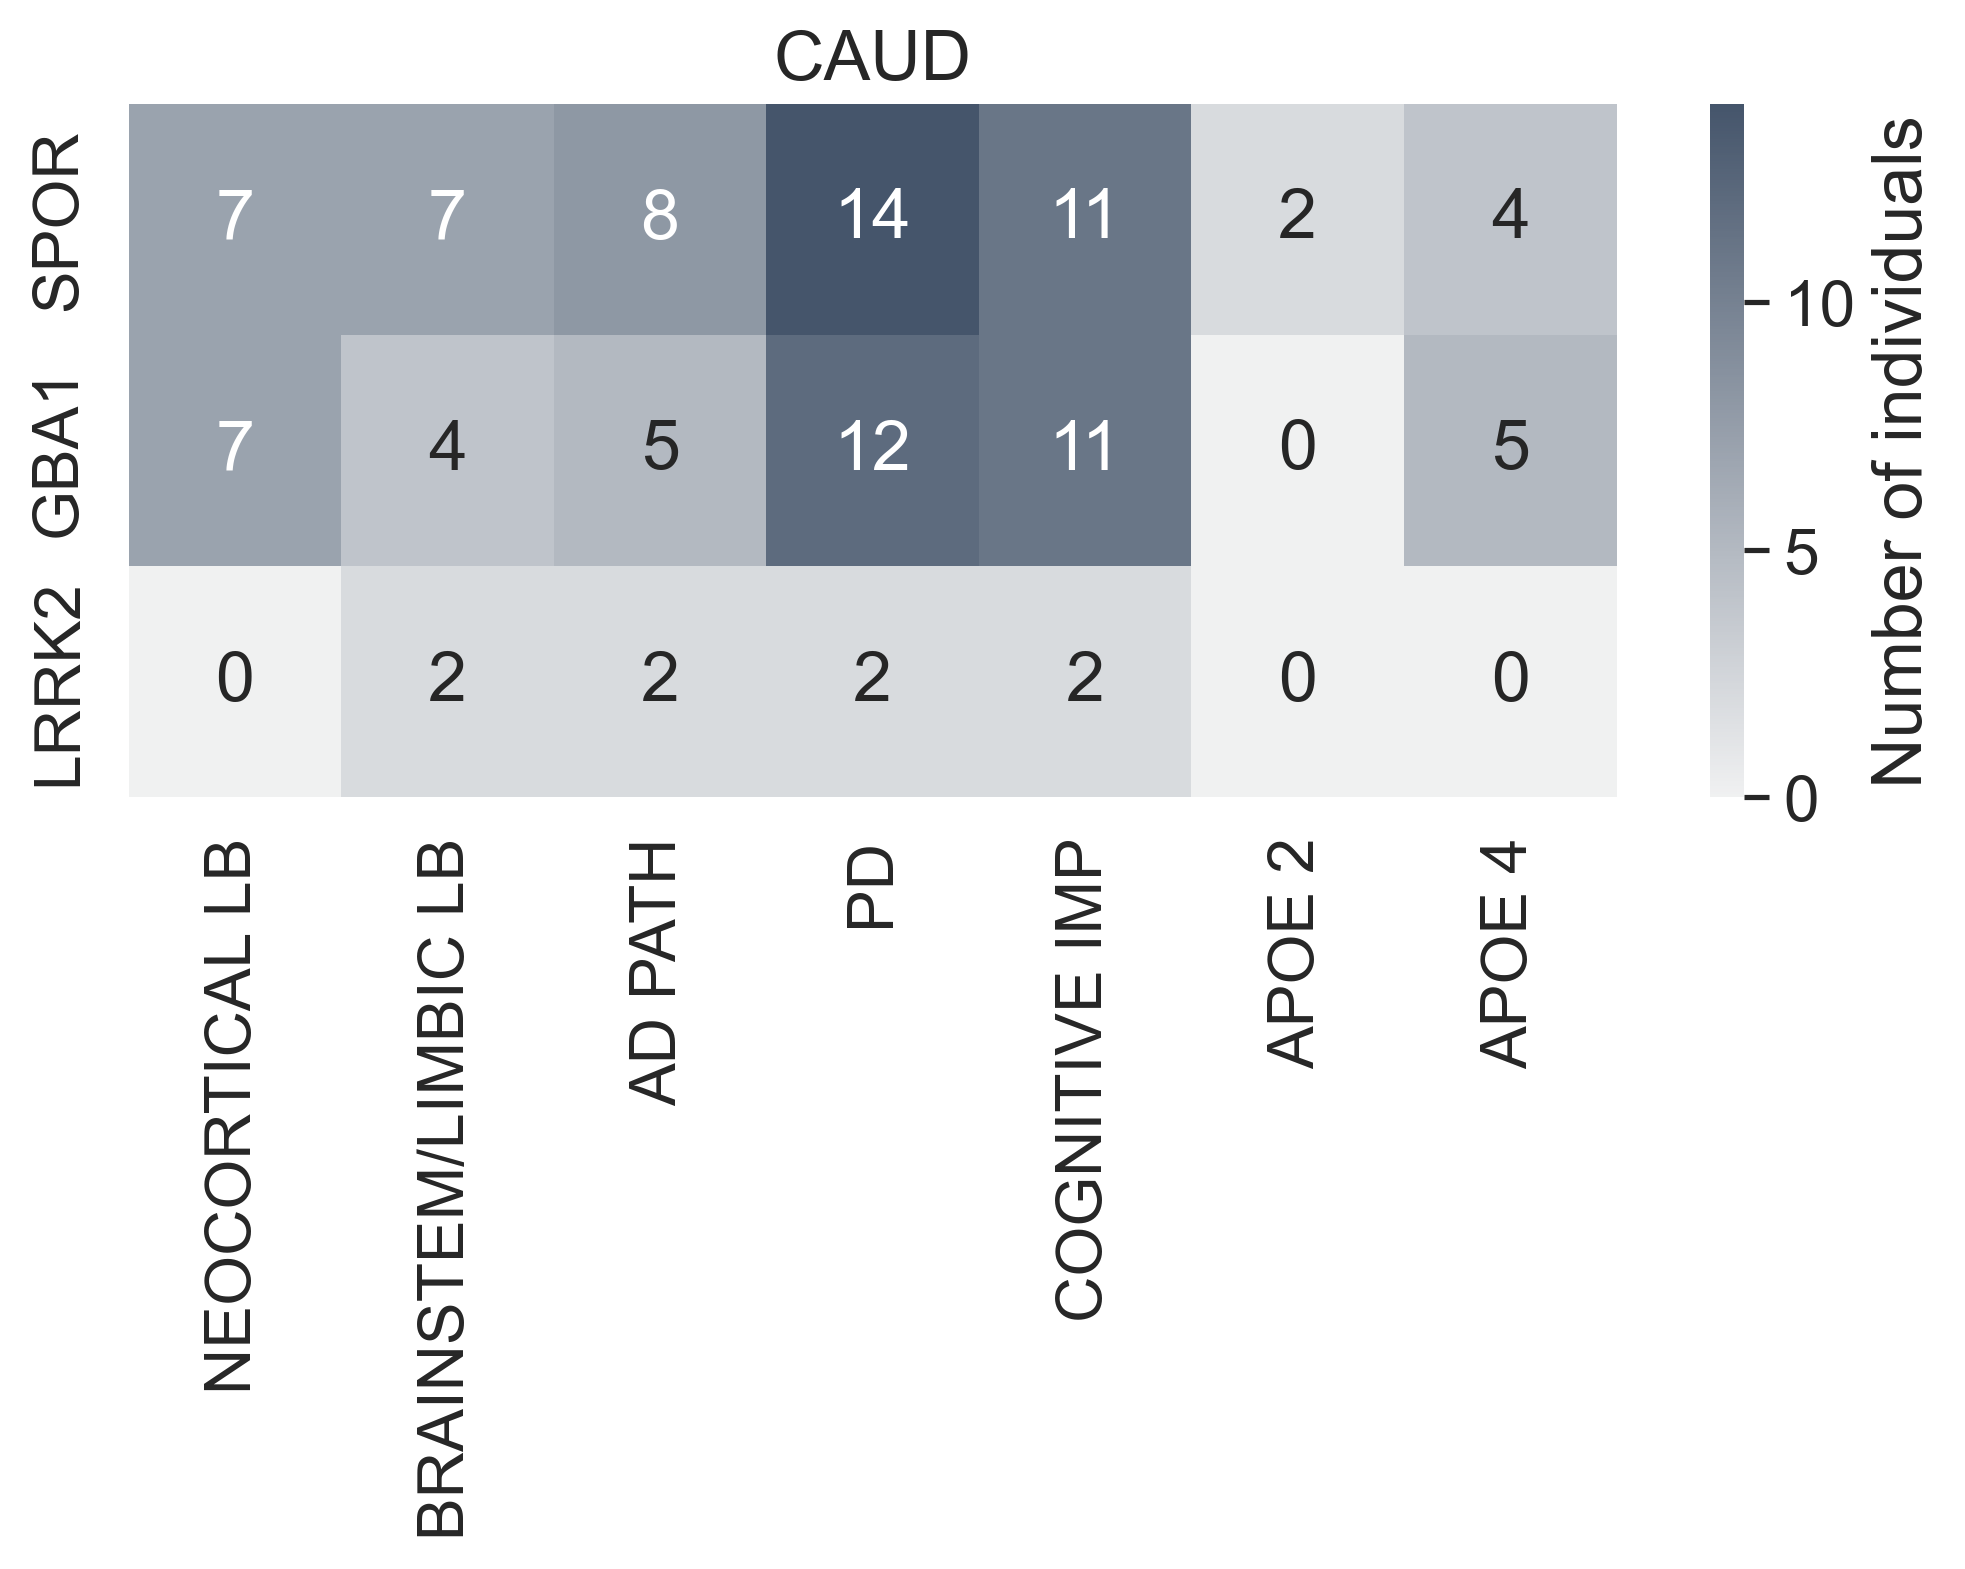

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


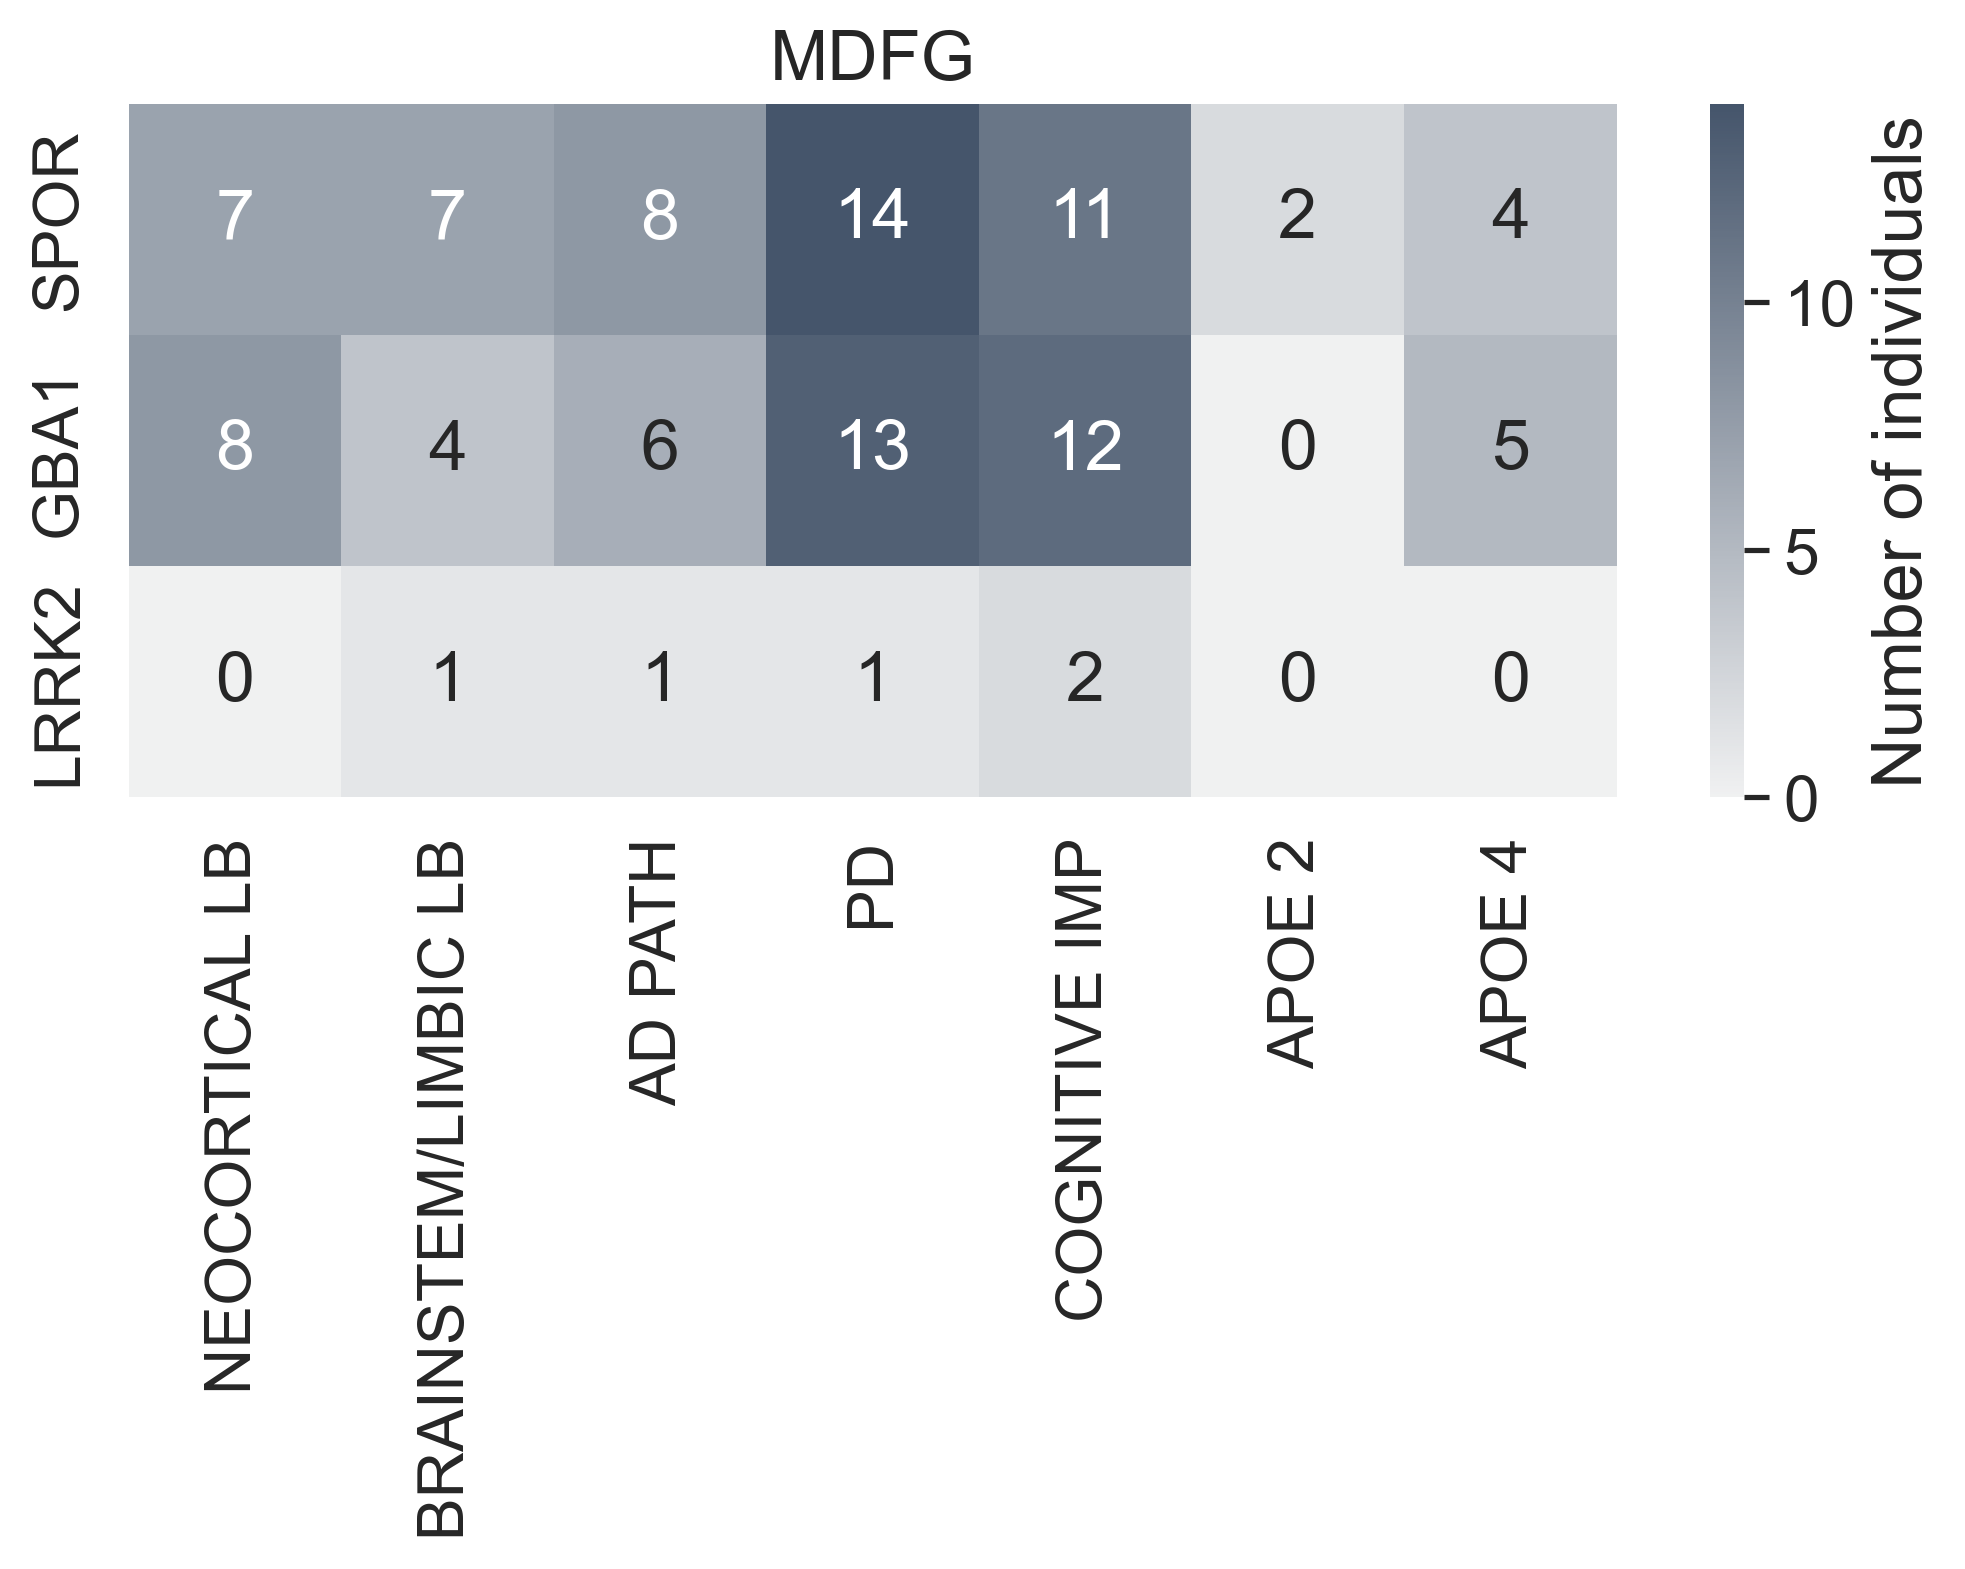

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


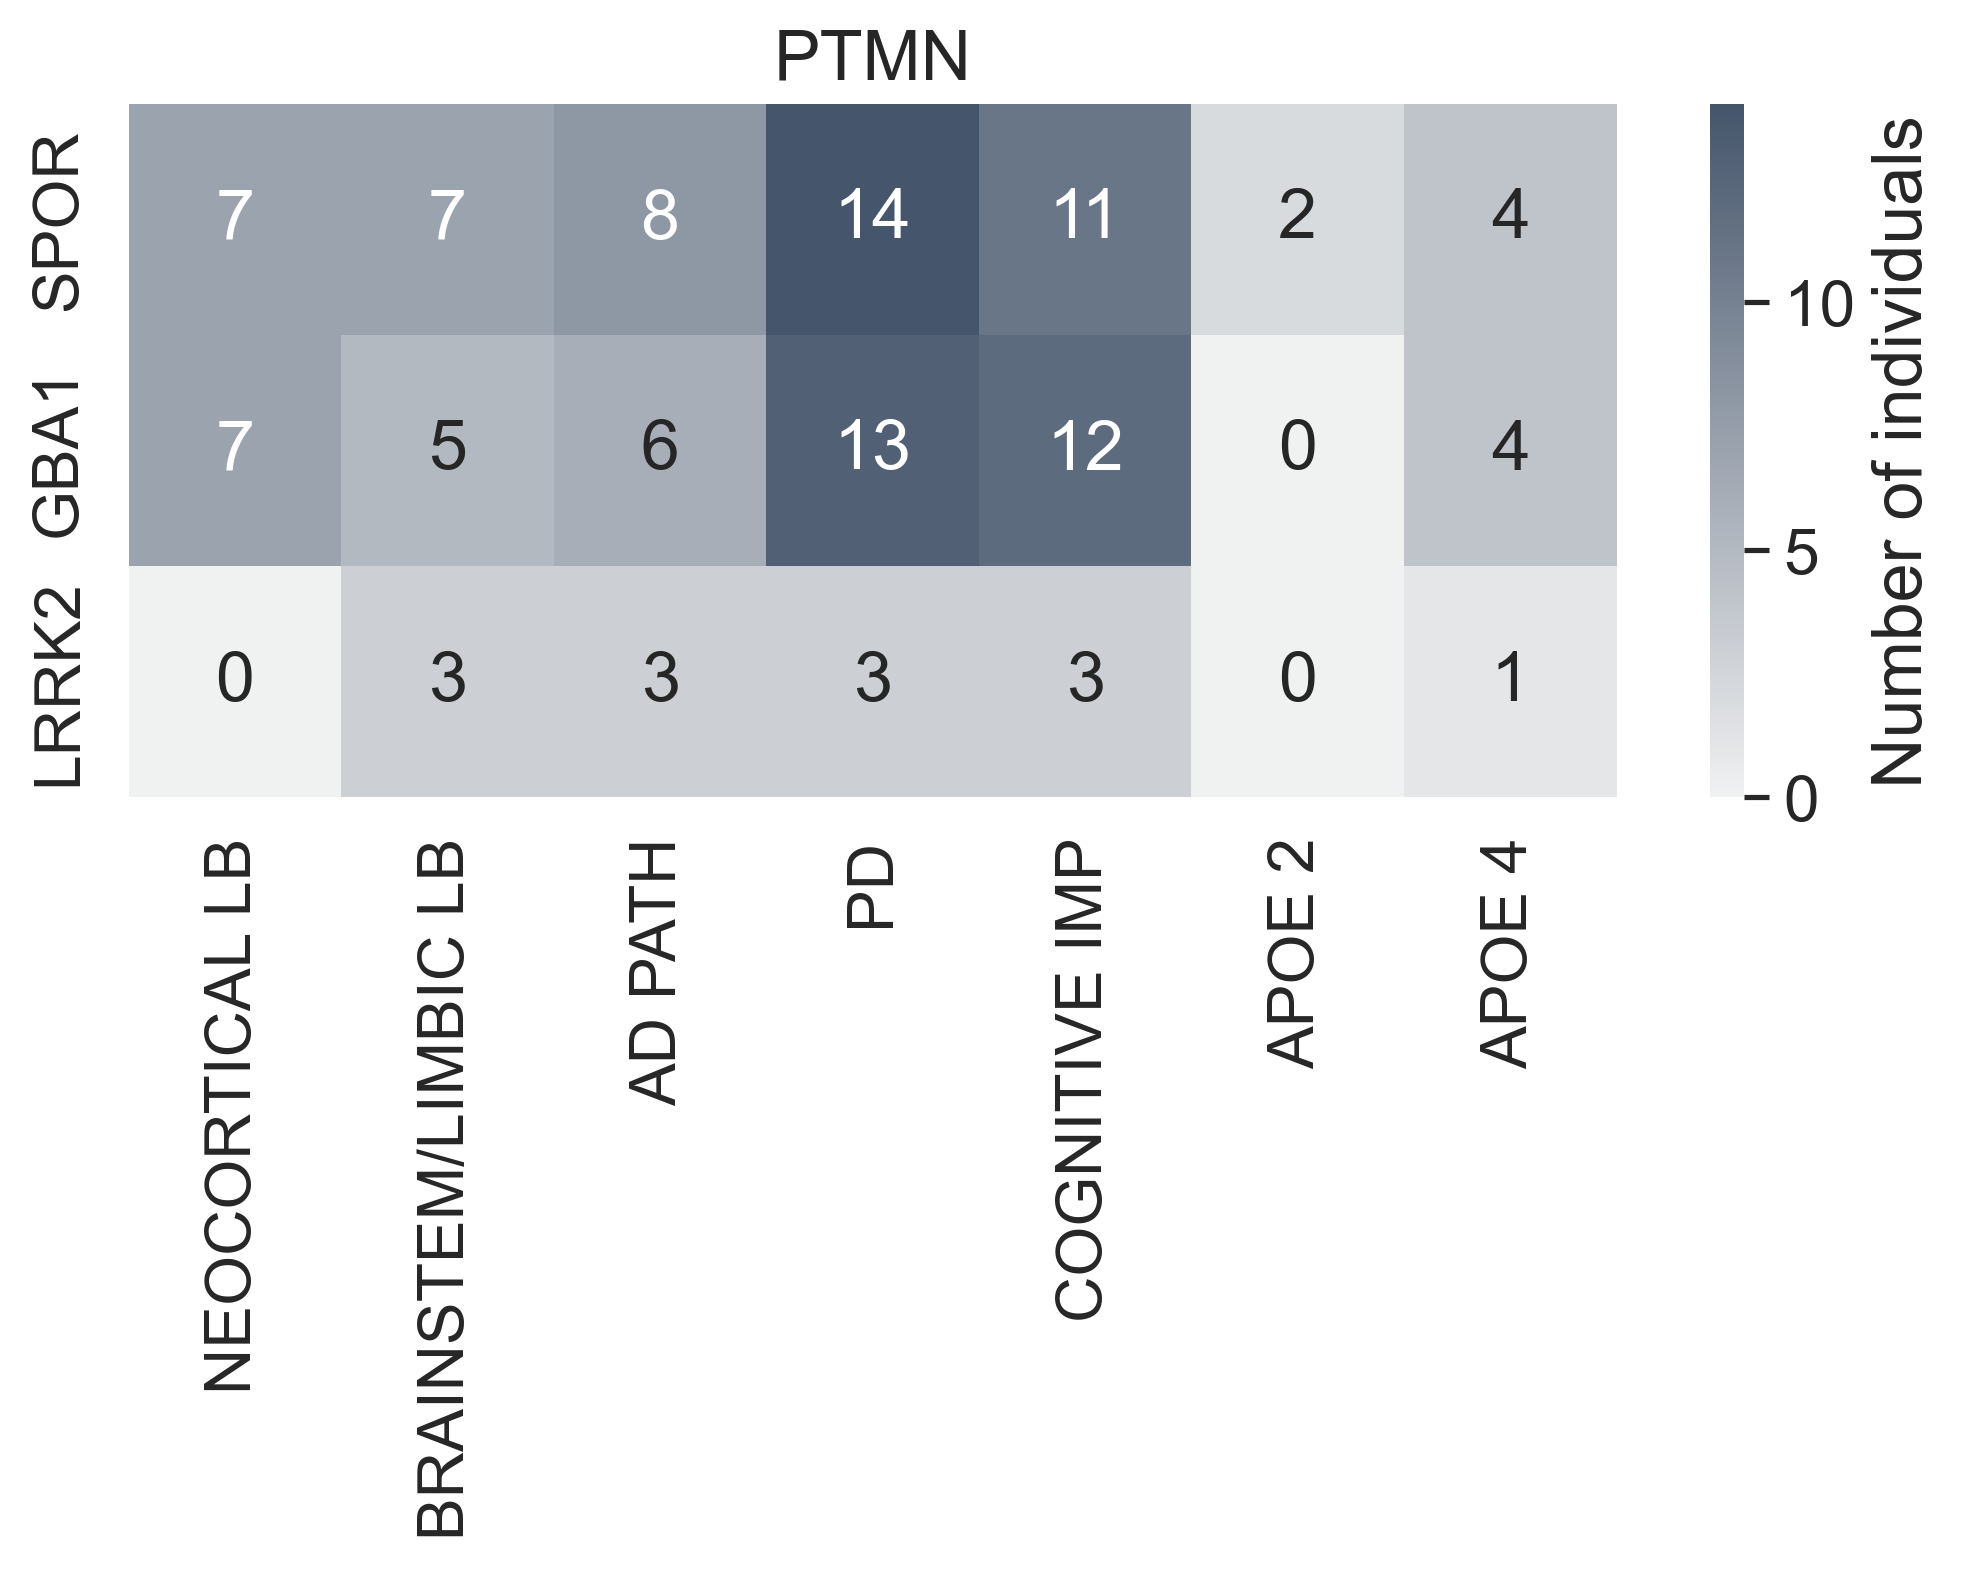

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_28389/1327172209.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, pval = spearmanr(x,y)


Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


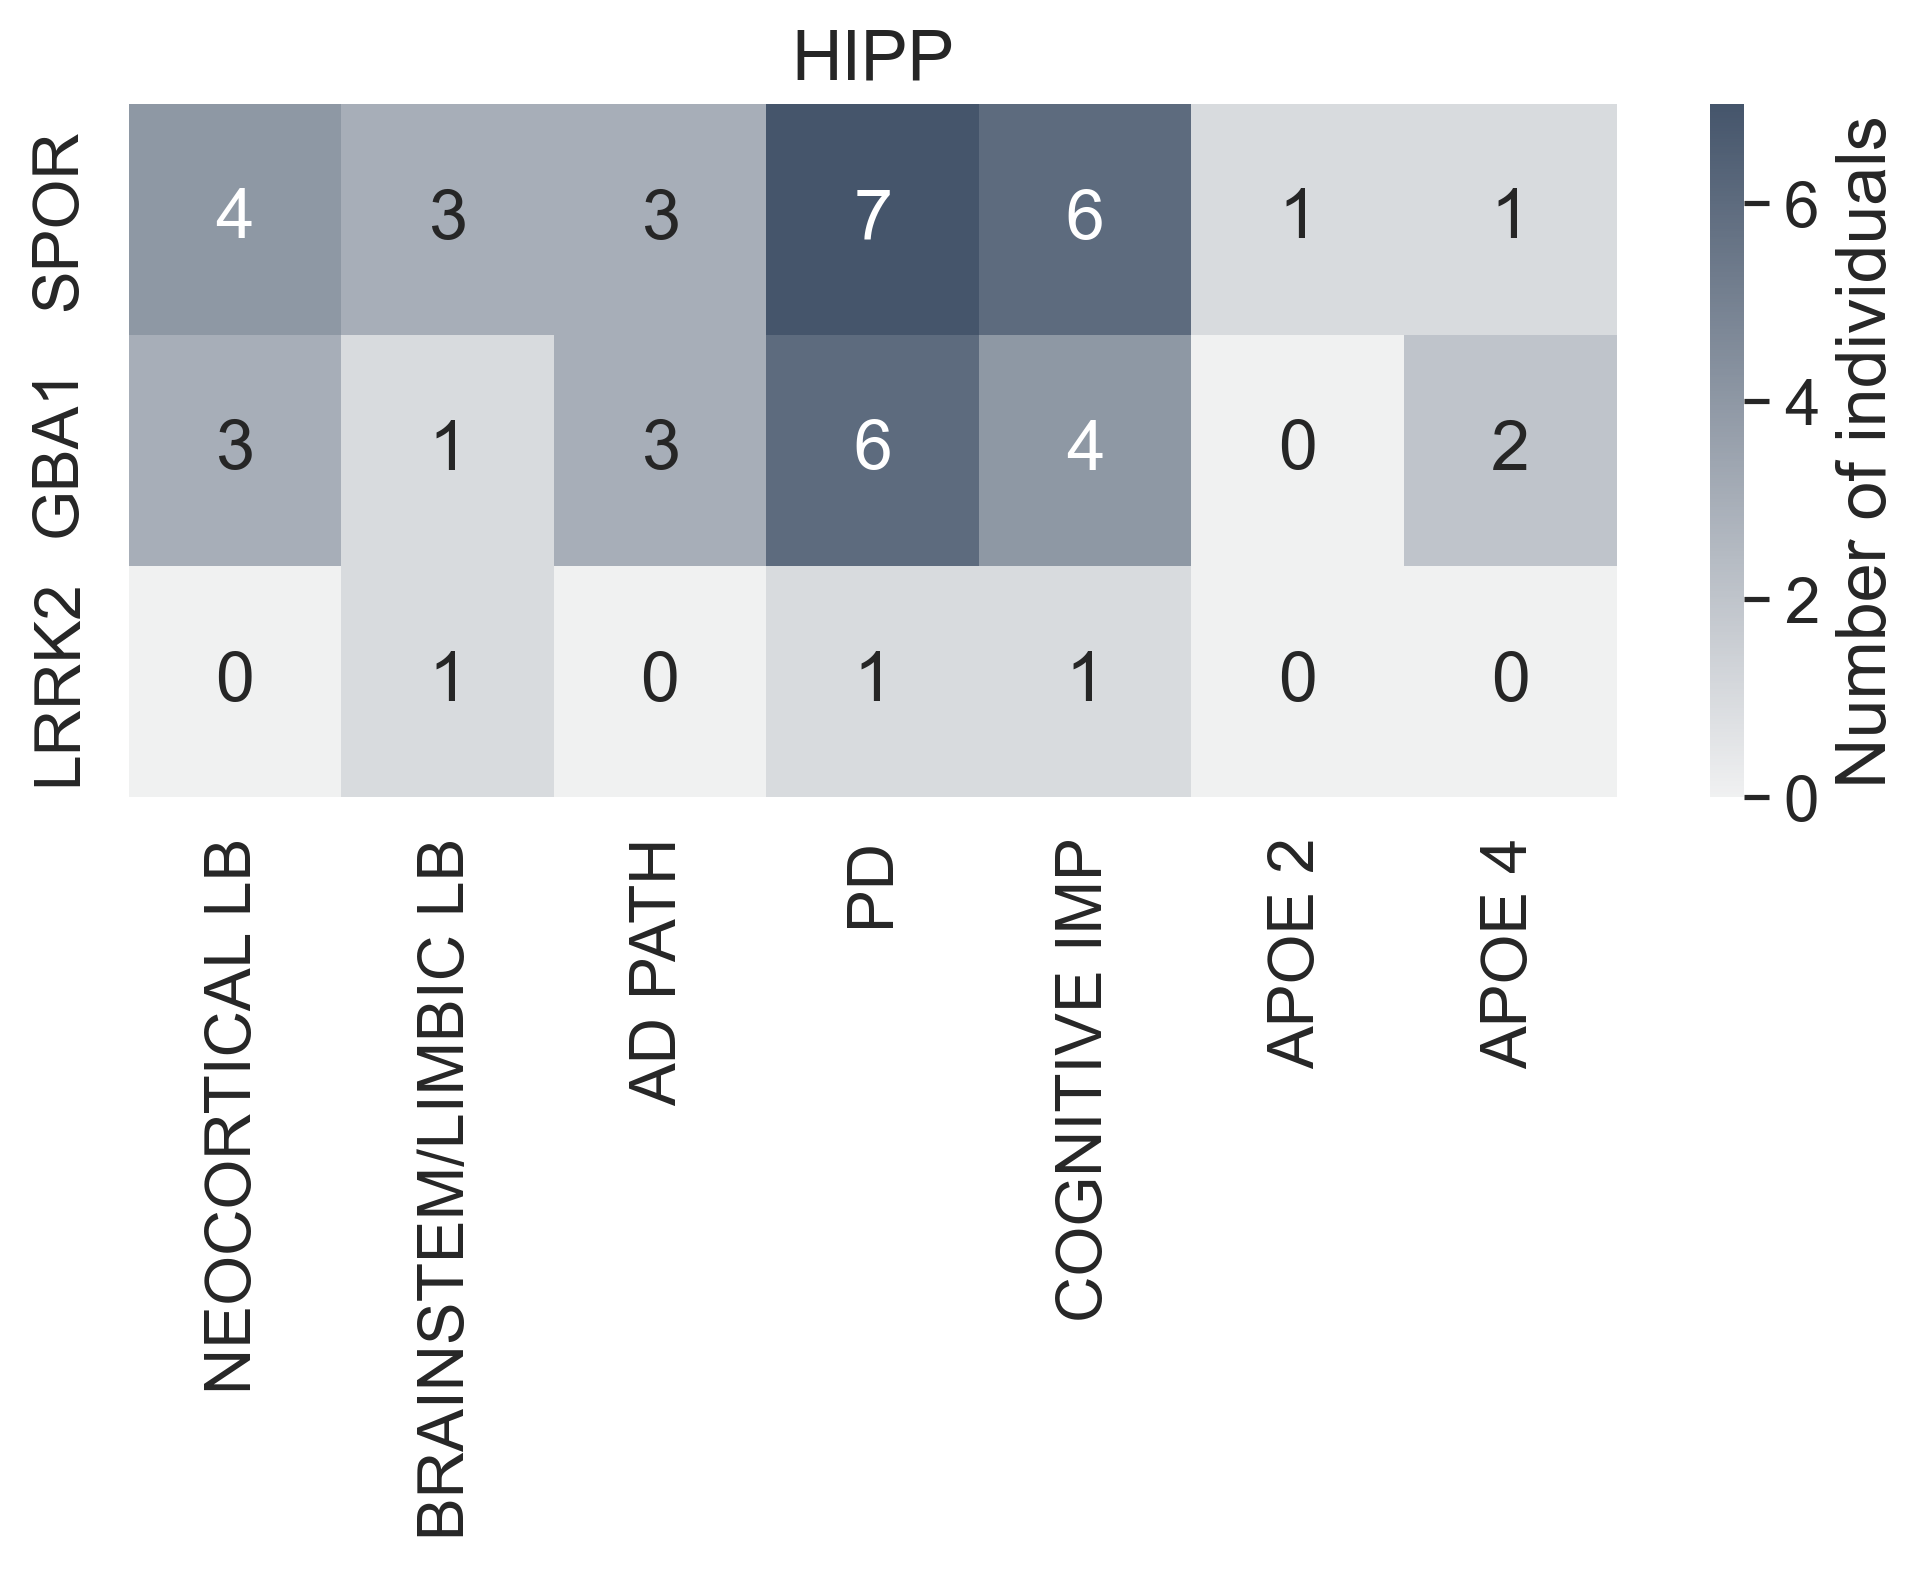

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


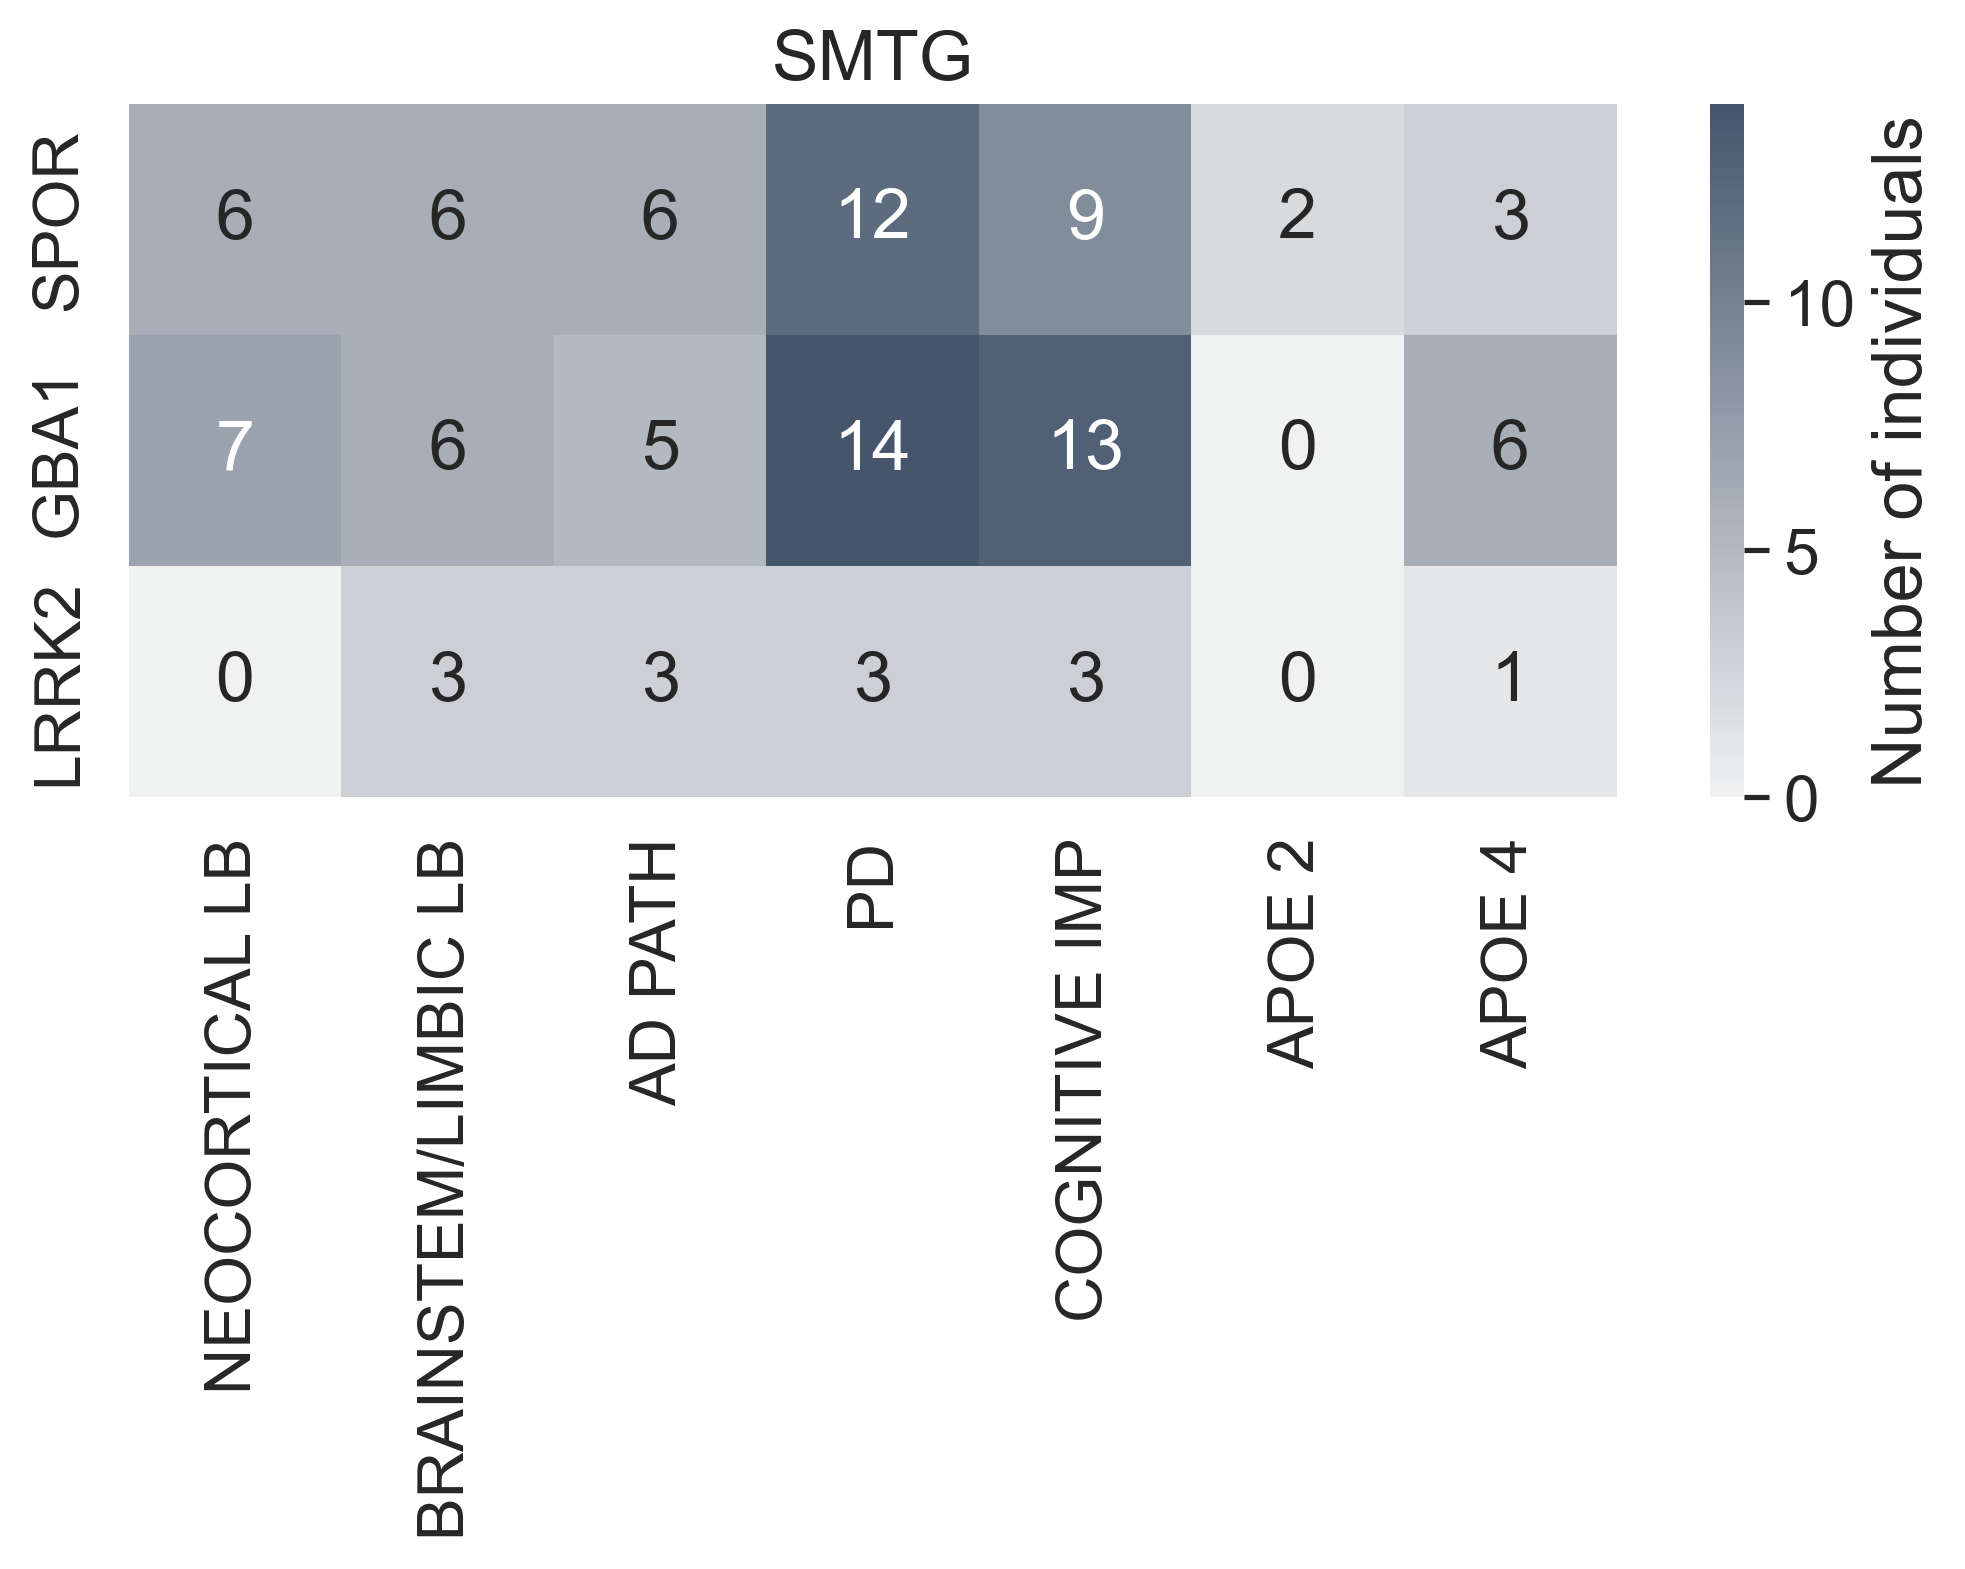

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'CTRL', 'GBA1', 'LRRK2', 'GBA1_PD+', 'Neuritic plaque density binary',
       'Braak score NFT binary', 'AD path', 'PD clinical', 'Cognitive Imp',
       'PD path'],
      dtype='object', length=117)


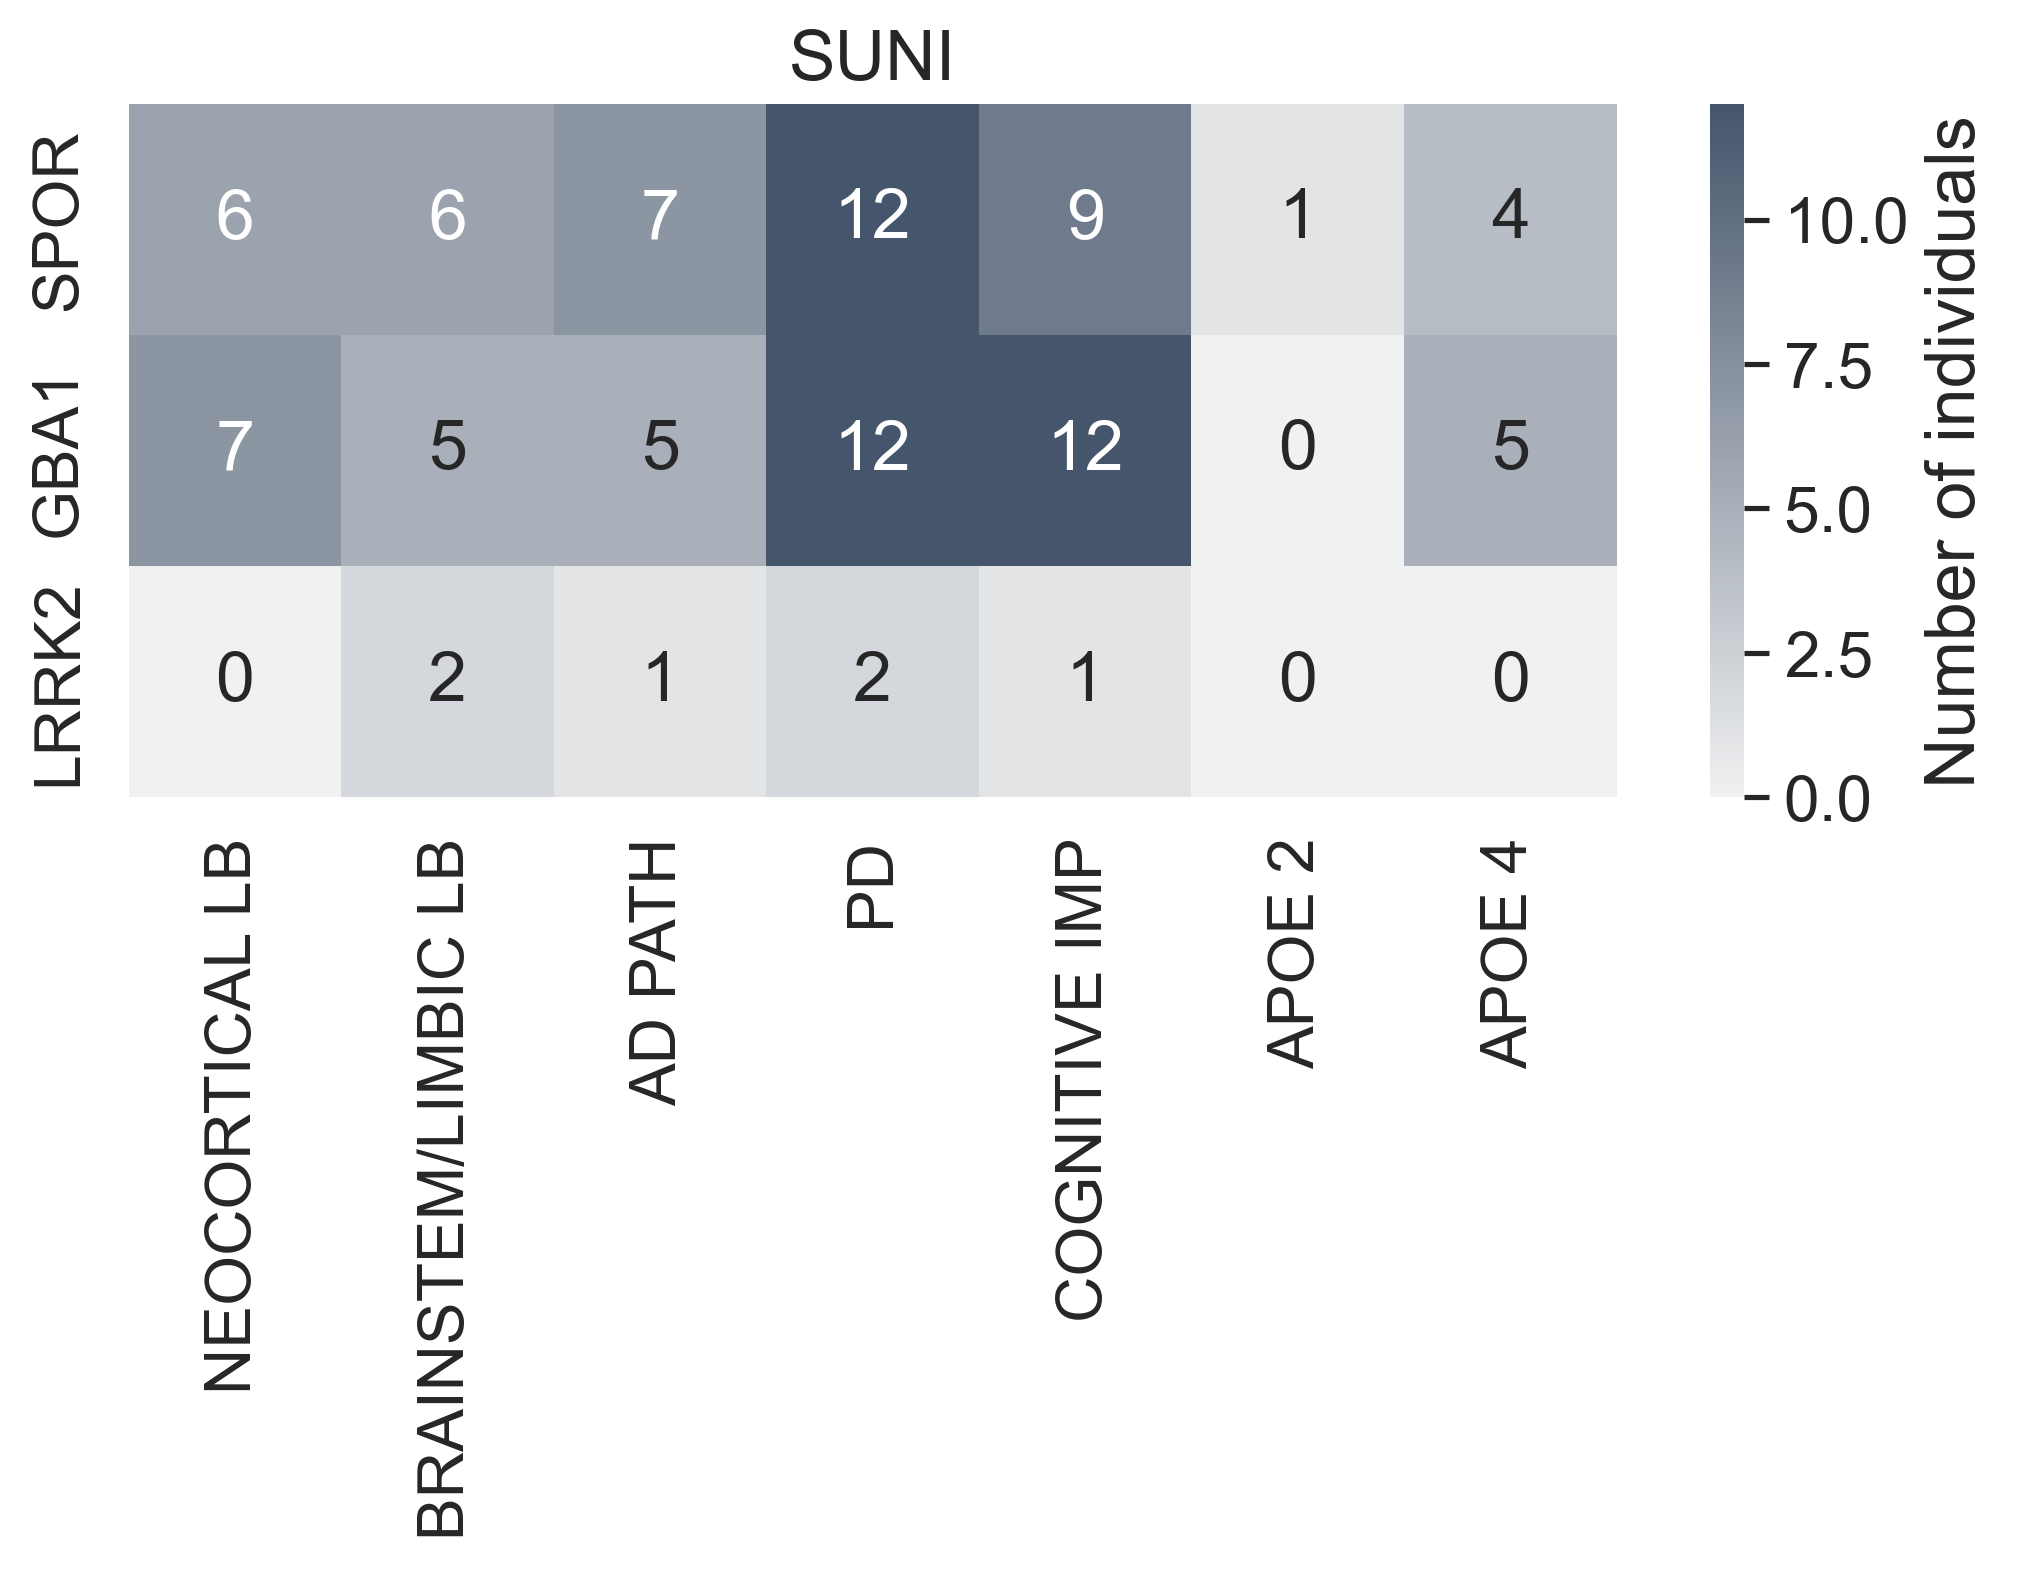

In [15]:
def getpvalue(x, y):
    _, pval = spearmanr(x,y)
    return pval
dico = { "Functions":functional,"Genotypes":genotype}

# for nam,it in dico.items():
# if True:
for br in adata.obs.brain_region.unique():
    
    tmp = adata[adata.obs.brain_region==br].obs[["PatientID"] + phenotype
                                +  functional + genotype].replace({"no":0, "yes":1, "low/no":0,"moderate/high":1}).astype(float)
    tmp = tmp.drop_duplicates("PatientID").drop("PatientID",axis=1)

    p = tmp.corr(method=getpvalue)
    
    mat = tmp.corr(method=getnum)
    print(adata.obs.columns)
    mat = mat.loc[phenotype,:][functional + genotype]
    p = p.loc[phenotype,:][functional + genotype]
    mat.columns = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in mat.columns.tolist()]
    p.columns = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in p.columns.tolist()]
    mat.index = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in mat.index.tolist()]
    p.index = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in p.index.tolist()]
    
    p = p*p.shape[0]*p.shape[1]
    p = p.applymap(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))

    sns.set(font_scale=1.4,style="white")
    fig, ax= plt.subplots(figsize=(8, 3))
    sns.heatmap(mat,cmap=cmap, annot=True, ax=ax, #fmt="s", 
                cbar_kws={"label":"Number of individuals"},
               linewidth=0.0)#, figsize=(12,12), dendrogram_ratio=0.1, cbar_kws={"label":"Pearson's R"})
    ax.set_title(br)

    plt.savefig(os.path.join(outdir, "heatmap_cormidity_interaction_%s.svg"%br))
    plt.show()


In [16]:
adata.obs.condition.unique()

adata.obs["condition"] = adata.obs["condition"].replace({"GBA1-PD+":"GBA1", "LRRK2-PD+":"LRRK2"})

phenotype = ["CTRL","SPOR", "GBA1",  "LRRK2"]
# pathology = ["Neocortical LB", "Brainstem/Limbic LB","Neuritic plaque density binary", "Braak score NFT binary"]#, "xxx.obt",'xxx.brain_stem_ix_x', 'xxx.brain_stem_lc', 'xxx.bf_amygdala', 'xxx.brain_stem_sn',
           # 'xxx.bf_trans', 'xxx.bf_cing', 'xxx.nctx_temporal', 'xxx.nctx_frontal','xxx.nctx_parietal']
functional = ["LB",  "ADNC", 'xxx.PD', "CI"]#"Neocortical LB", "Brainstem/Limbic LB",
functional2 = ["LB",  "ADNC", 'xxx.PD']

func_2 = ["Dementia nos", "AD dementia/MCI"]
genotype= ["ApoE_2", "ApoE_4"]

adata.obs["ADNC"] = adata.obs["AD path"].values
adata.obs["CI"] = adata.obs["Cognitive Imp"].values

In [17]:
adata.obs["LB"] = adata.obs['xxx.Unified LB Stage'].map({"0. No Lewy bodies":0,"lV. Neocortical":2,
                                                     "lll. Brainstem/Limbic":1,"lla. Brainstem Predominant":1,
                                                               "llb. Limbic Predominant":1}).values

Index(['celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch',
       'PatientID', 'Unnamed: 0', 'Sample_id', 'Name',
       ...
       'GBA1_PD+', 'Neuritic plaque density binary', 'Braak score NFT binary',
       'AD path', 'PD clinical', 'Cognitive Imp', 'PD path', 'ADNC', 'CI',
       'LB'],
      dtype='object', length=120)


/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_49448/714399140.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, pval = spearmanr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_49448/714399140.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(x,y)


,LB,ADNC,PD,CI,APOE 2,APOE 4
LB,,,,,,
ADNC,,,,,,
PD,,,,,,
CI,,,,,,
APOE 2,,,,,,
APOE 4,,,,,,


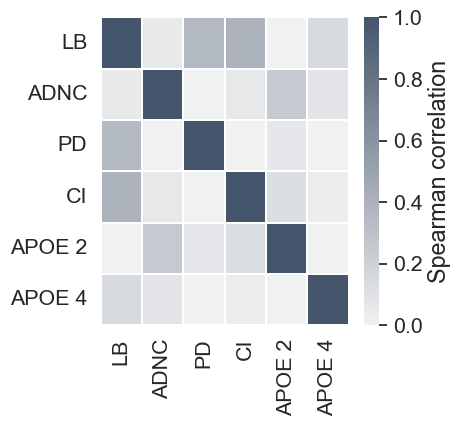

In [9]:
def getpvalue(x, y):
    val_ind = np.where((x!=np.nan)&(y!=np.nan))
    x = x[val_ind]
    y = y[val_ind]
    _, pval = spearmanr(x,y)
    return pval
def getspearman(x, y):
    val_ind = np.where((x!=np.nan)&(y!=np.nan))
    x = x[val_ind]
    y = y[val_ind]
    sp, _ = spearmanr(x,y)
    return sp

def getnum(x, y):
    val_ind = np.where((x!=np.nan)&(y!=np.nan))[0]
    x = x[val_ind]
    y = y[val_ind]

    num = np.where((y==1) &(x==1) &(x==y))[0]
    # print(num)
    return len(num)


# for nam,it in dico.items():
if True:
    tmp = adata.obs[["PatientID"] + phenotype + functional + genotype].replace({"no":0, "yes":1, "low/no":0, "moderate/high":1}).astype(float)
    tmp = tmp.drop_duplicates("PatientID").drop("PatientID",axis=1)

    p = tmp.corr(method=getpvalue)
    
    mat = tmp.corr(method=getspearman)
    print(adata.obs.columns)
    mat = mat.loc[functional + genotype,:][ functional + genotype]
    p = p.loc[functional + genotype,:][ functional + genotype]
    mat.columns = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in mat.columns.tolist()]
    p.columns = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in p.columns.tolist()]
    mat.index = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in mat.index.tolist()]
    p.index = [it.replace("xxx.","").replace("is_","").replace("_"," ").upper() for it in p.index.tolist()]
    
    p = p*p.shape[0]*p.shape[1]
    p = p.applymap(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))

    sns.set(font_scale=1.4,style="white")
    fig, ax= plt.subplots(figsize=(4, 4))
    sns.heatmap(mat.T,cmap=cmap,  ax=ax, fmt="s", annot=p.T, #mat.astype(int).T,
                cbar_kws={"label":"Spearman correlation"},vmin=0, vmax=1,
               linewidth=0.2)#, figsize=(12,12), dendrogram_ratio=0.1, cbar_kws={"label":"Pearson's R"})
    # plt.show()

plt.savefig(os.path.join(outdir, "heatmap_cormidity_interaction.svg"))
# plt.savefig(outdir + "/covariate_patient_correlation.svg")
p